<a href="https://colab.research.google.com/github/georgiaop/-Sistema-Banc-rio/blob/main/analise_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ******TITANIC******



# **Importando as Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%writefile requirements.text
pandas
numpy
matplotlib
seaborn

Writing requirements.text


# **Carregamento dos Dados**

In [3]:
titanic=pd.read_csv("/content/titanic.csv" , sep=',', decimal= ".")


In [4]:
titanic.shape

(891, 9)

titanic.head()

# **Tratamento dos Dados**

O DataFrame do pandas é a estrutura que contém os bancos de dados no formato tabular.


**Informações gerais do DataFrame**
info()

 Quantidade de linhas, colunas, quais tipos(ajuda identificar se é texto que já remete uma variável categórica - qualitativa, números que já remete uma variável métrica - quantitativa), nome das variáveis, quantidade de não nulos(dados preenchidos) que já identifica se há dados faltantes(nulos- Missing Values).



In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sobreviveu       891 non-null    object 
 1   classe           891 non-null    object 
 2   sexo             891 non-null    object 
 3   idade            714 non-null    float64
 4   irmaos_conjuges  891 non-null    int64  
 5   pais_filhos      891 non-null    int64  
 6   valor_tarifa     891 non-null    float64
 7   nivel_cabine     203 non-null    object 
 8   embarque         889 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 62.8+ KB


In [6]:
titanic.isnull().sum()

,0
sobreviveu,0
classe,0
sexo,0
idade,177
irmaos_conjuges,0
pais_filhos,0
valor_tarifa,0
nivel_cabine,688
embarque,2


In [7]:
type(titanic)

pandas.core.frame.DataFrame

Selecionar a variável que quiser, ou mais de uma  variável criando uma lista.

In [8]:
classe = titanic['classe']

In [9]:
classe.head()

,classe
0,terceira
1,primeira
2,terceira
3,primeira
4,terceira


In [10]:
selecao_var = titanic[["sobreviveu","classe","sexo"]]
selecao_var.head()


,sobreviveu,classe,sexo
0,nao,terceira,masculino
1,sim,primeira,feminino
2,sim,terceira,feminino
3,sim,primeira,feminino
4,nao,terceira,masculino


*Remover variável que não tem interesse*


drop()

usei selecao_var = selecao_var.drop(columns=["classe"])
Saiu do DataFrame a coluna classe.

In [11]:
selecao_var.columns


Index(['sobreviveu', 'classe', 'sexo'], dtype='object')

pode criar uma lista e remover mais de uma variável.

selecao_var=selecao_var.drop(columns[["sexo","classe"]])


In [12]:
selecao_var.columns

Index(['sobreviveu', 'classe', 'sexo'], dtype='object')

**Filtrar**

É possível filtrar (selecionar) observações por meio de condições.
Operadores para realizar os filtros:

== igual, < menor, <= menor ou igual, > maior, >= maior ou igual, != diferente, & indica e (a intersecção entre critérios),

 | indica ou (união de critérios, se quiser trabalhar com mais de um critério.)

In [13]:
sobreviveu = titanic [titanic['sobreviveu'] =='sim']
sobreviveu = titanic[titanic['sobreviveu'] != 'nao']
sobreviveu.head()

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
1,sim,primeira,feminino,38.0,1,0,71.2833,C,Cherbourg
2,sim,terceira,feminino,26.0,0,0,7.9250,NaN,Southampton
3,sim,primeira,feminino,35.0,1,0,53.1000,C,Southampton
8,sim,terceira,feminino,27.0,0,2,11.1333,NaN,Southampton
9,sim,segunda,feminino,14.0,1,0,30.0708,NaN,Cherbourg


Masculinos maiores de 18 anos

In [14]:
masc_adultos = (titanic[(titanic['sexo'] == 'masculino') &
                        (titanic['idade'] >= 18)])
masc_adultos.head()

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
0,nao,terceira,masculino,22.0,1,0,7.2500,NaN,Southampton
4,nao,terceira,masculino,35.0,0,0,8.0500,NaN,Southampton
6,nao,primeira,masculino,54.0,0,0,51.8625,E,Southampton
12,nao,terceira,masculino,20.0,0,0,8.0500,NaN,Southampton
13,nao,terceira,masculino,39.0,1,5,31.2750,NaN,Southampton


In [15]:
masc_adultos.shape

(395, 9)

Mulheres e crianças

In [16]:
mulheres_criancas = (titanic[(titanic['sexo'] == 'feminino') |
                             (titanic['idade'] < 18)])
mulheres_criancas.head()



,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
1,sim,primeira,feminino,38.0,1,0,71.2833,C,Cherbourg
2,sim,terceira,feminino,26.0,0,0,7.9250,NaN,Southampton
3,sim,primeira,feminino,35.0,1,0,53.1000,C,Southampton
7,nao,terceira,masculino,2.0,3,1,21.0750,NaN,Southampton
8,sim,terceira,feminino,27.0,0,2,11.1333,NaN,Southampton


In [17]:
mulheres_criancas.shape

(372, 9)

Pessoas sozinhas sem parentes

In [18]:
sozinhos = (titanic[(titanic['irmaos_conjuges'] == 0) &
                    (titanic['pais_filhos'] == 0)])
sozinhos.head()

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
2,sim,terceira,feminino,26.0,0,0,7.9250,NaN,Southampton
4,nao,terceira,masculino,35.0,0,0,8.0500,NaN,Southampton
5,nao,terceira,masculino,NaN,0,0,8.4583,NaN,Queenstown
6,nao,primeira,masculino,54.0,0,0,51.8625,E,Southampton
11,sim,primeira,feminino,58.0,0,0,26.5500,C,Southampton


Pessoas que pagaram mais de $100 pela tarifa e embarcaram em Cherbourg



In [19]:
tarifas_embarque = (titanic[(titanic['valor_tarifa'] > 100) &
                            (titanic['embarque'] == 'Cherbourg')])
tarifas_embarque.head()

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
31,sim,primeira,feminino,NaN,1,0,146.5208,B,Cherbourg
118,nao,primeira,masculino,24.0,0,1,247.5208,B,Cherbourg
195,sim,primeira,feminino,58.0,0,0,146.5208,B,Cherbourg
215,sim,primeira,feminino,31.0,1,0,113.2750,D,Cherbourg
258,sim,primeira,feminino,35.0,0,0,512.3292,NaN,Cherbourg


Pessoas que pagaram mais de $100 pela tarifa e embarcaram em Southampton

In [20]:
tarifas_embarque = (titanic[(titanic['valor_tarifa'] > 100) &
                            (titanic['embarque'] == 'Southampton')])
tarifas_embarque.head()

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
27,nao,primeira,masculino,19.0,3,2,263.0000,C,Southampton
88,sim,primeira,feminino,23.0,3,2,263.0000,C,Southampton
268,sim,primeira,feminino,58.0,0,1,153.4625,C,Southampton
269,sim,primeira,feminino,35.0,0,0,135.6333,C,Southampton
297,nao,primeira,feminino,2.0,1,2,151.5500,C,Southampton


# **Limpeza de Dados**

In [21]:
titanic.isnull().sum()

,0
sobreviveu,0
classe,0
sexo,0
idade,177
irmaos_conjuges,0
pais_filhos,0
valor_tarifa,0
nivel_cabine,688
embarque,2


In [22]:
titanic_limpo = titanic.dropna()
#desta forma, seria uma opção ruim para este banco de dados,
#pois uma das variáveis (nível da cabine) tem muitos valores faltantes,
#com isso a base de dados ficaria menor, de 891 informações ficariam 182
#O ideal seria excluir a variável nível da cabine,
#tem pouca informação e mais dados faltantes
titanic_limpo.shape


(182, 9)

In [23]:
#primeiro faz a exclusão da coluna que quer excluir,
#em seguida o dropna que será realizada
#nos dados faltantes das variáveis que ficaram,
#com isso o banco de dados de 891 ficará 712.

titanic_limpo = titanic.drop(columns=['nivel_cabine']).dropna()
titanic_limpo.shape

(712, 8)

In [24]:
titanic_limpo.columns
#coluna nível da cabine não aparece entre as variáveis, pois foi excluida.

Index(['sobreviveu', 'classe', 'sexo', 'idade', 'irmaos_conjuges',
       'pais_filhos', 'valor_tarifa', 'embarque'],
      dtype='object')

In [25]:
titanic_limpo.isnull().sum()
#contagem dos dados nulos,
#depois do dropna que usamos para excluir os dados faltantes.

,0
sobreviveu,0
classe,0
sexo,0
idade,0
irmaos_conjuges,0
pais_filhos,0
valor_tarifa,0
embarque,0


# **Análise Exploratória**

**Estatísticas descritivas**

O direcionamento das técnicas depende das variáveis, se são Categóricas(qualitativas) ou métricas (quantitativas).



Variáveis quantitativa tabela de frequências

A Estatística descritiva básica para as variáveis categóricas é uma tabela de freqências(absolutas e relativas). São contagens por categorias.

In [26]:
# epecifico qual variável que tenho interesse no caso (sobreviveu sim ou não).
#não estou usando o limpo, estou usando o banco de dados completo.
titanic['sobreviveu'].value_counts()
# Esta é a frequência absoluta

,count
sobreviveu,
nao,549
sim,342


In [27]:
# Esta é a frequência relativa
# (normalize=True)traz a frequência relativa
#62% não sobreviveram
#38% sobreviveram
titanic['sobreviveu'].value_counts(normalize=True)



,proportion
sobreviveu,
nao,0.616162
sim,0.383838


 **normalize=True** é um argumento do values_counts pede que ele seja verdadeiro, no values_count() o argumento fica vazio porque o argumento é padrão default e o padrao já é False, então se já é False tem que usar o True no normalize.

 **values_counts**  traz uma frequência absoluta que é a contagem absoluta em observada cada categorias das variáveis qualitativas, ou seja as contagens linha pos linha.

**normalize=True** faz com que isso passe ser uma freqência relativa em relação ao total de observações

 Exemplo:

  549 que não sobreviveram dividido por 891 total de observacoes = 62% não sobreviveram.

  342 que sobreviveram dividido por 891 total de observações  = 38% sobreviveram.


In [28]:
#não sobreviveu dividido pelo total da amostra= 62%
549/891

0.6161616161616161

In [29]:
0.616162 + 0.383838


1.0

DataFrame dos filtros para ver se as proporcões mudam.

In [30]:
sozinhos['sobreviveu'].value_counts(normalize=True)
# as pessoas que estavam sozinhos,
#percentual mais elevados de não sobreviveram
#esta mais elevado que na amostra completa
#70% nao sobreviveram
#30% sobreviveram

,proportion
sobreviveu,
nao,0.696462
sim,0.303538


In [31]:
masc_adultos['sobreviveu'].value_counts(normalize=True)
# foram salvas mulheres e crianças primeiro.
# mortalidade dos adultos sexo masculinos é elevada
# 82% não sobreviveram.
# 18% sobreviveram

,proportion
sobreviveu,
nao,0.822785
sim,0.177215


**Estatísticas descritivas**

*   **variável quantitativa**:

Medidas de posição:


In [32]:
# Contagem de observações
titanic['idade'].count()

np.int64(714)

In [33]:
#Média aritmética é uma estimativa ( a idade media dos passageiros tinham 30 anos )
titanic['idade'].mean()

np.float64(29.69911764705882)

In [34]:
# Mediana não é a mesma coisa que média (metade das pessoas tinham idade menor ou igual 28 anos,
# outra metade tinham maior ou igual a 28 anos)
titanic['idade'].median()


28.0

In [35]:
# a idade máxima 80 anos
titanic['idade'].max()


80.0

In [36]:
# a idade minima recém nascido, menos de 1 ano.
#temos uma amplitude de menos de 0,42 anos(menos de 1 ano) até 80 anos com uma media de 28 anos.
titanic['idade'].min()


0.42

**Quartis**

  São os elementos da distribuição da variável que dividem as observações em quadro partes iguais, considerando que a variável esteja com seus valores organizados de forma crescente

 primeiro quartil:(percentil 25): 25% das observações são menores do que o primeiro quartil

 segundo quartil:(percentil 50): 50% é a mediana

 terceiro quartil:(percentil 75): 25% das observações são maiores ou iguais do que o terceiro terceiro quartil.


In [37]:
# Quartis e Percentis
#percentil 25,
#ou seja 25% da minha amostra tinham idade menor ou igual a 20 anos.
titanic['idade'].quantile(q = 0.25) # Primeiro Quartil


np.float64(20.125)

In [38]:
# percentil 75%
# 25% tinham idade maior ou igual 38 anos.

titanic['idade'].quantile(q = 0.75) # Terceiro Quartil


# OU SEJA 50% DA AMOSTRA VARIAM  ENTRE 20 E 38 ANOS DE IDADE.

np.float64(38.0)

**Médida de dispersão**

**variância e Desvio padrão**

  *  Variância: dispersão das observações de uma variável em torno de sua média (desvio em relação a media, estão juntos da média ou espalhados, dispersos).

  *   Desvio padrão: é a raiz quadrada da variância

  Variância baixa e dispersão baixa todos juntos

  Variância alta e dispersão alta todos dispersos, dispersão dos valores.

In [39]:
# Variância
titanic['idade'].var()
#

211.0191247463081

In [40]:
# Desvio padrão
titanic['idade'].std()


14.526497332334044

**Temos todas as Estastísticas na função describe()**

In [41]:
# Tabela de descritivas
titanic['idade'].describe()




,idade
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [42]:
titanic[['idade', 'valor_tarifa']].describe()

,idade,valor_tarifa
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [43]:
titanic.describe()

,idade,irmaos_conjuges,pais_filhos,valor_tarifa
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


**Estatísticas descritivas: agrupadas por meio de critério qualitativo**


In [44]:
# Qual é o valor médio da tarifa por classe?
#média aritimética das classes: primeira, segunda e terceira
titanic[['classe', 'valor_tarifa']].groupby(by=['classe']).mean()


,valor_tarifa
classe,
primeira,84.154687
segunda,20.662183
terceira,13.675550


In [45]:
# Percentual de sobreviventes por sexo

titanic[['sobreviveu', 'sexo']].groupby('sexo')['sobreviveu'].value_counts(normalize=True)



sexo       sobreviveu
feminino   sim           0.742038
           nao           0.257962
masculino  nao           0.811092
           sim           0.188908
Name: proportion, dtype: float64

In [46]:
# Percentual de sobreviventes por classe

titanic[['sobreviveu', 'classe']].groupby('classe')['sobreviveu'].value_counts(normalize=True)


classe    sobreviveu
primeira  sim           0.629630
          nao           0.370370
segunda   nao           0.527174
          sim           0.472826
terceira  nao           0.757637
          sim           0.242363
Name: proportion, dtype: float64

#**Data Visualization**

intuito é a análise exploratória dos dados por meio dos gráficos.




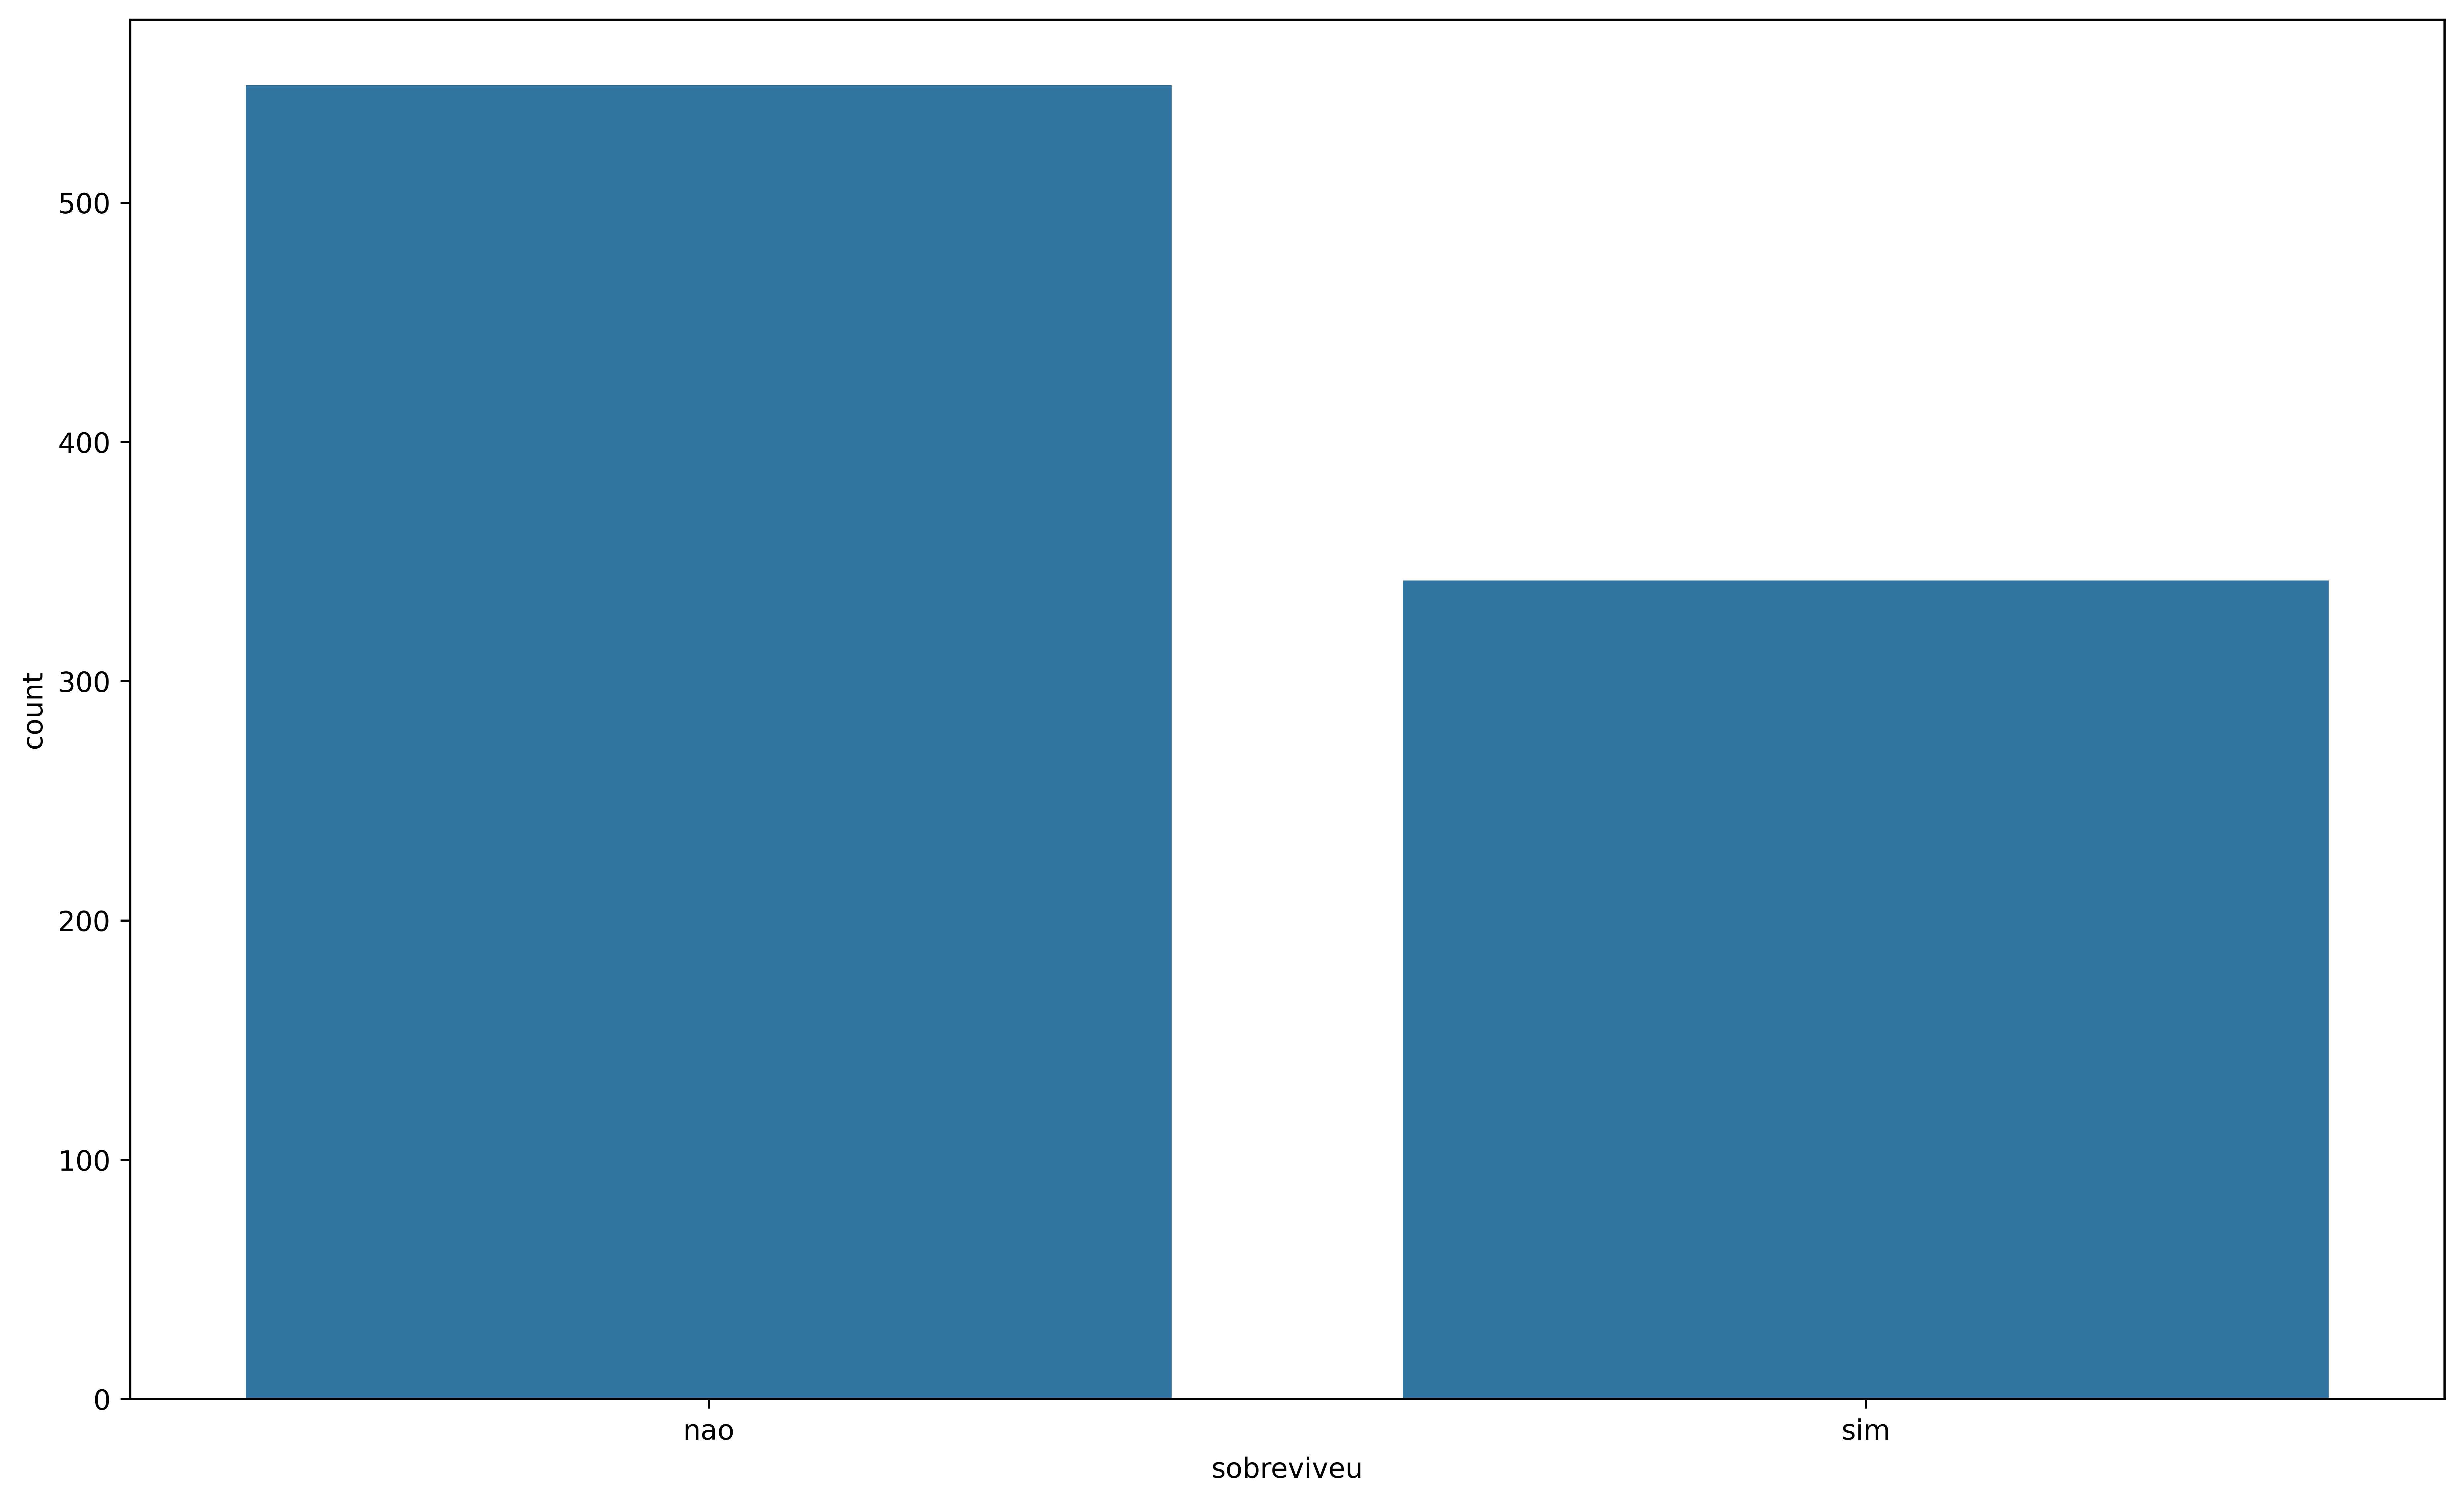

In [47]:
#%% Gráfico de barras para contagem

# Vamos iniciar por uma variável qualitativa
# Como é variável categórica, vamos criar um gráfico de contagem (countplot)
# Neste caso, o gráfico apresentará a contagem em cada categoria da variável
# usando gráfico do seborn e formatando com
# elementos do matplotlib, usamos as duas bibliotecas juntos.
# O dpi é para resolução, ajustar a quantidade de pixel.

#countplot mostra tabela de frequências

plt.figure(figsize=(15,9), dpi=600)
sns.countplot(data=titanic, x='sobreviveu')
plt.show()

# Vamos adicionar algumas formatações ao gráfico básico



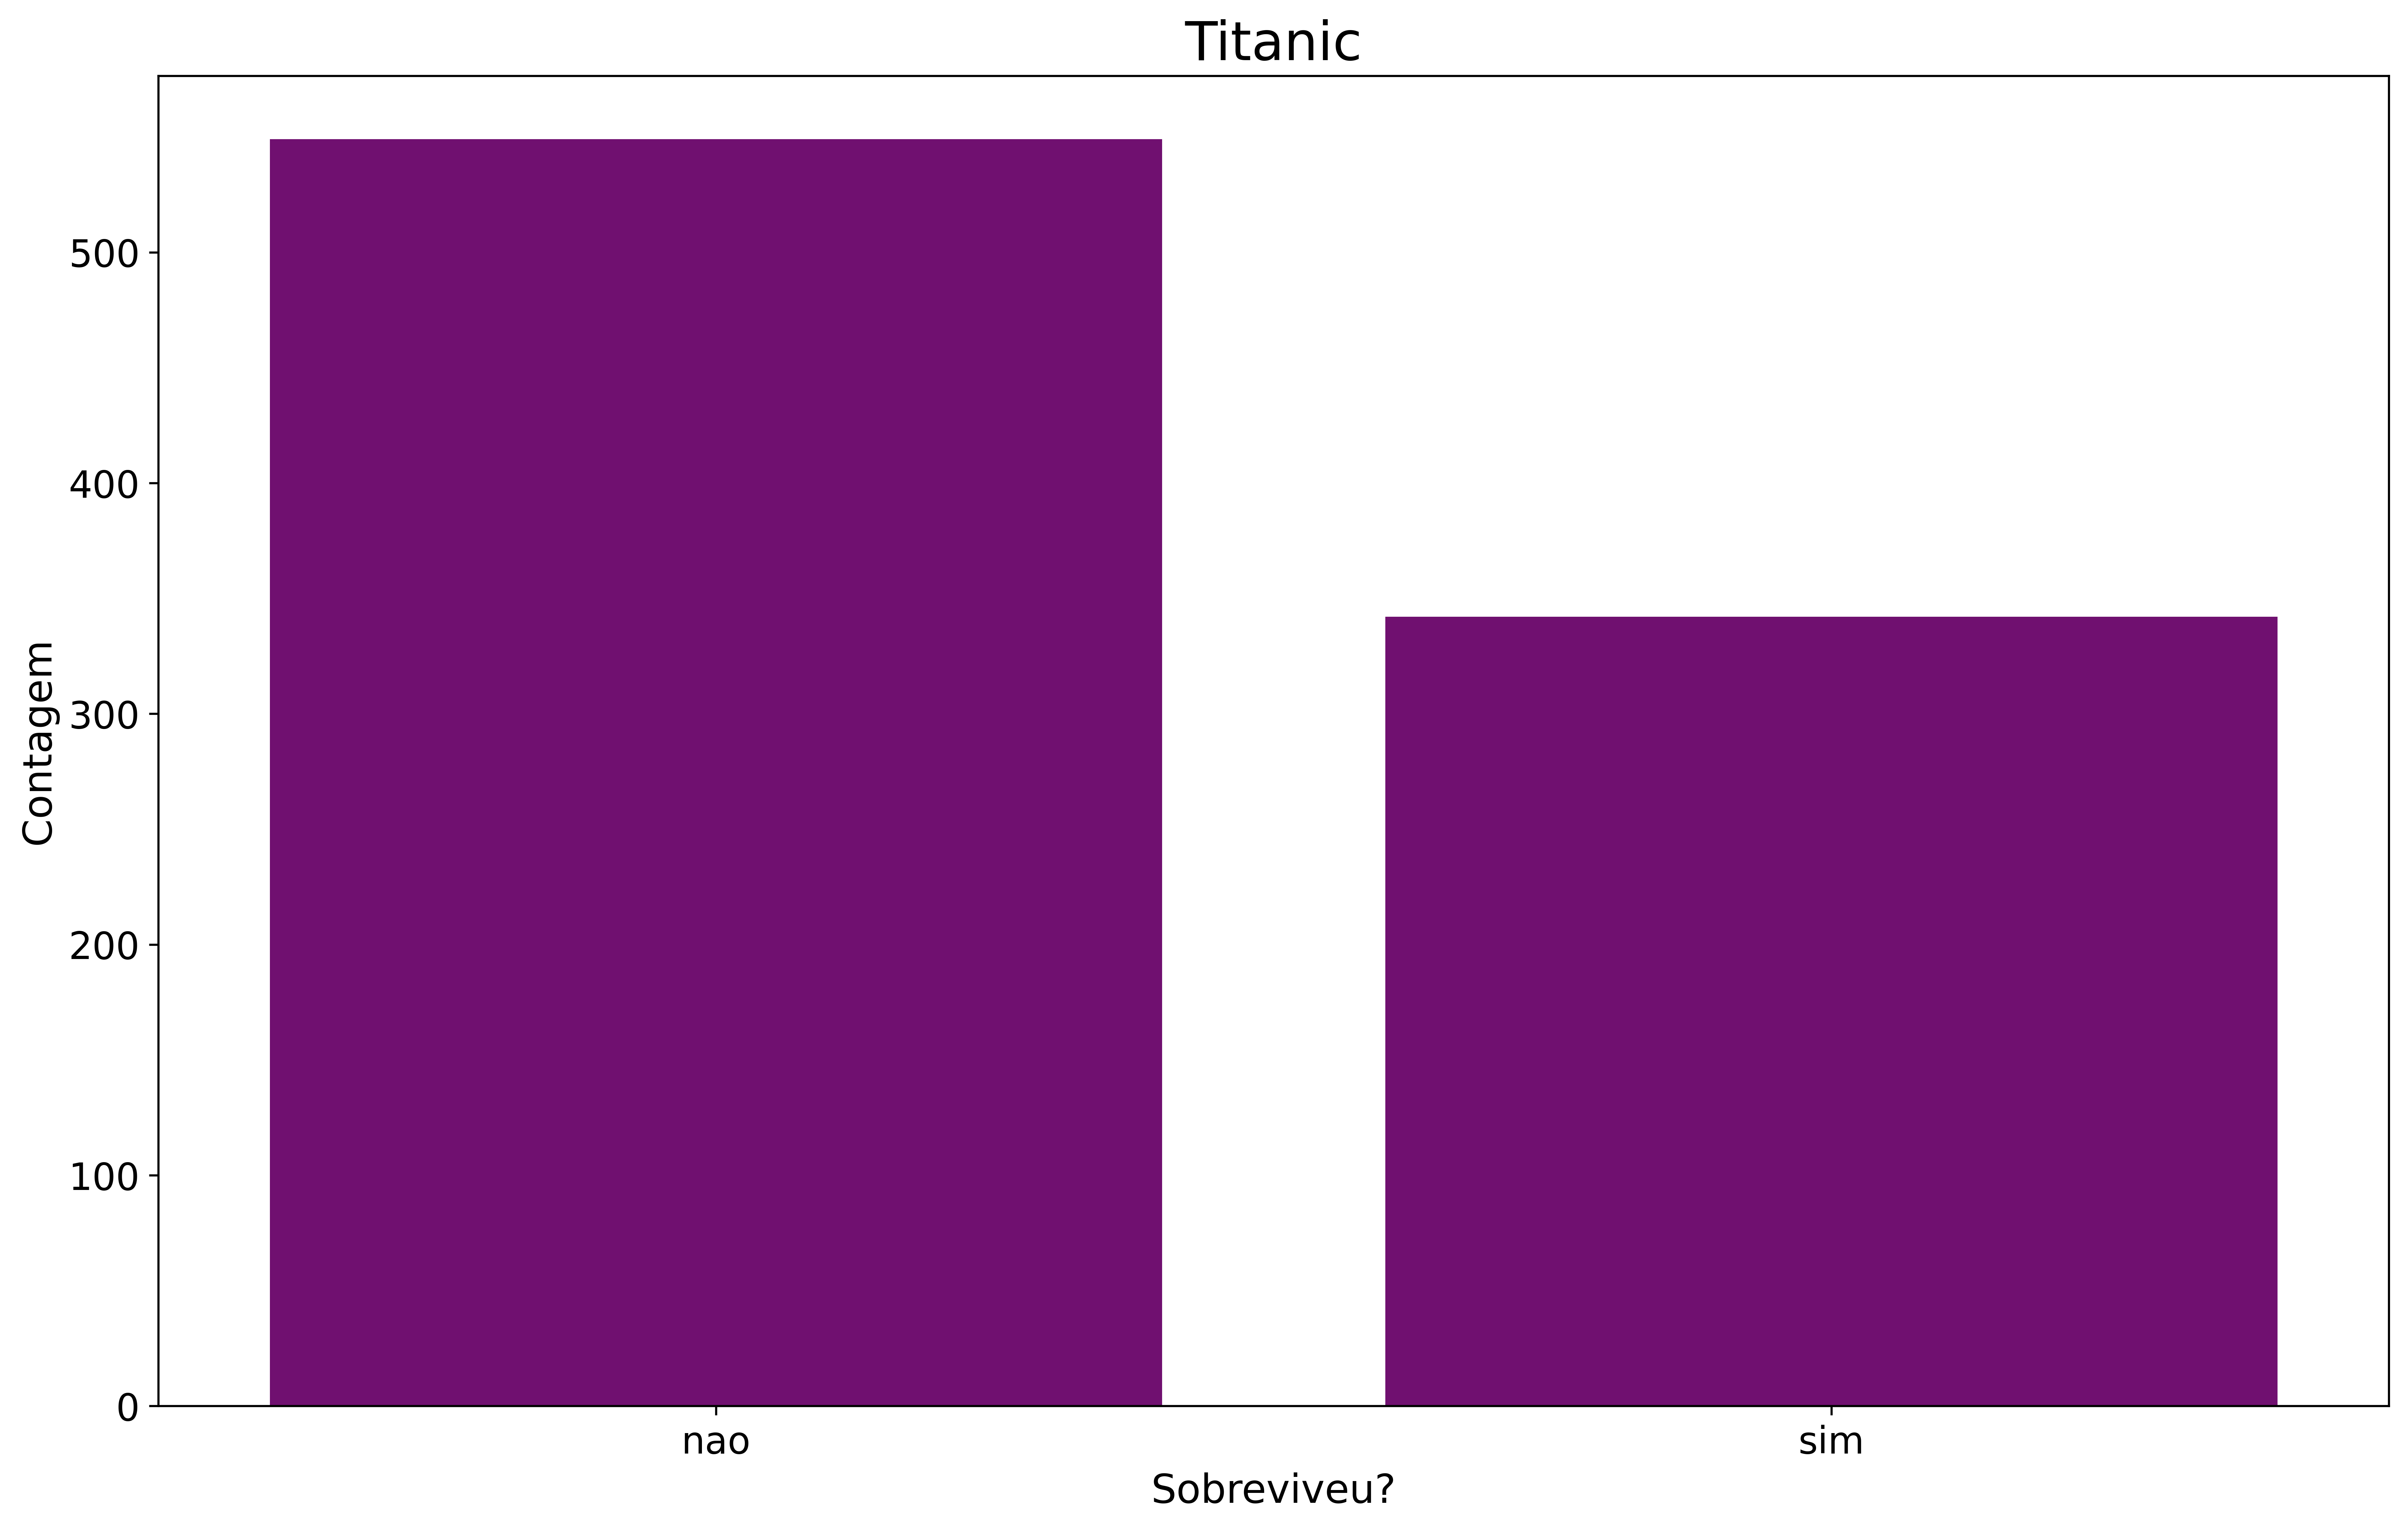

In [48]:
# adicionar algumas formatações ao gráfico básico

plt.figure(figsize=(15,9), dpi=600)# tamanho do grafico, píxel
sns.countplot(data=titanic, x='sobreviveu', color='purple')#colocar cor
plt.title('Titanic',fontsize=20)#adcionando titulo, e tamanho da fonte
plt.xlabel('Sobreviveu?',fontsize=15)# rotulo do eixo x, tamanho da fonte
plt.ylabel('Contagem',fontsize=15)# rotulo do eixo y, tamanho da fonte
plt.xticks(fontsize=14)#tamanho da fonte dos ticks (nome) no eixo x
plt.yticks(fontsize=14)#tamanho da fonte  dos ticks (valores) no  eixo y
plt.show()

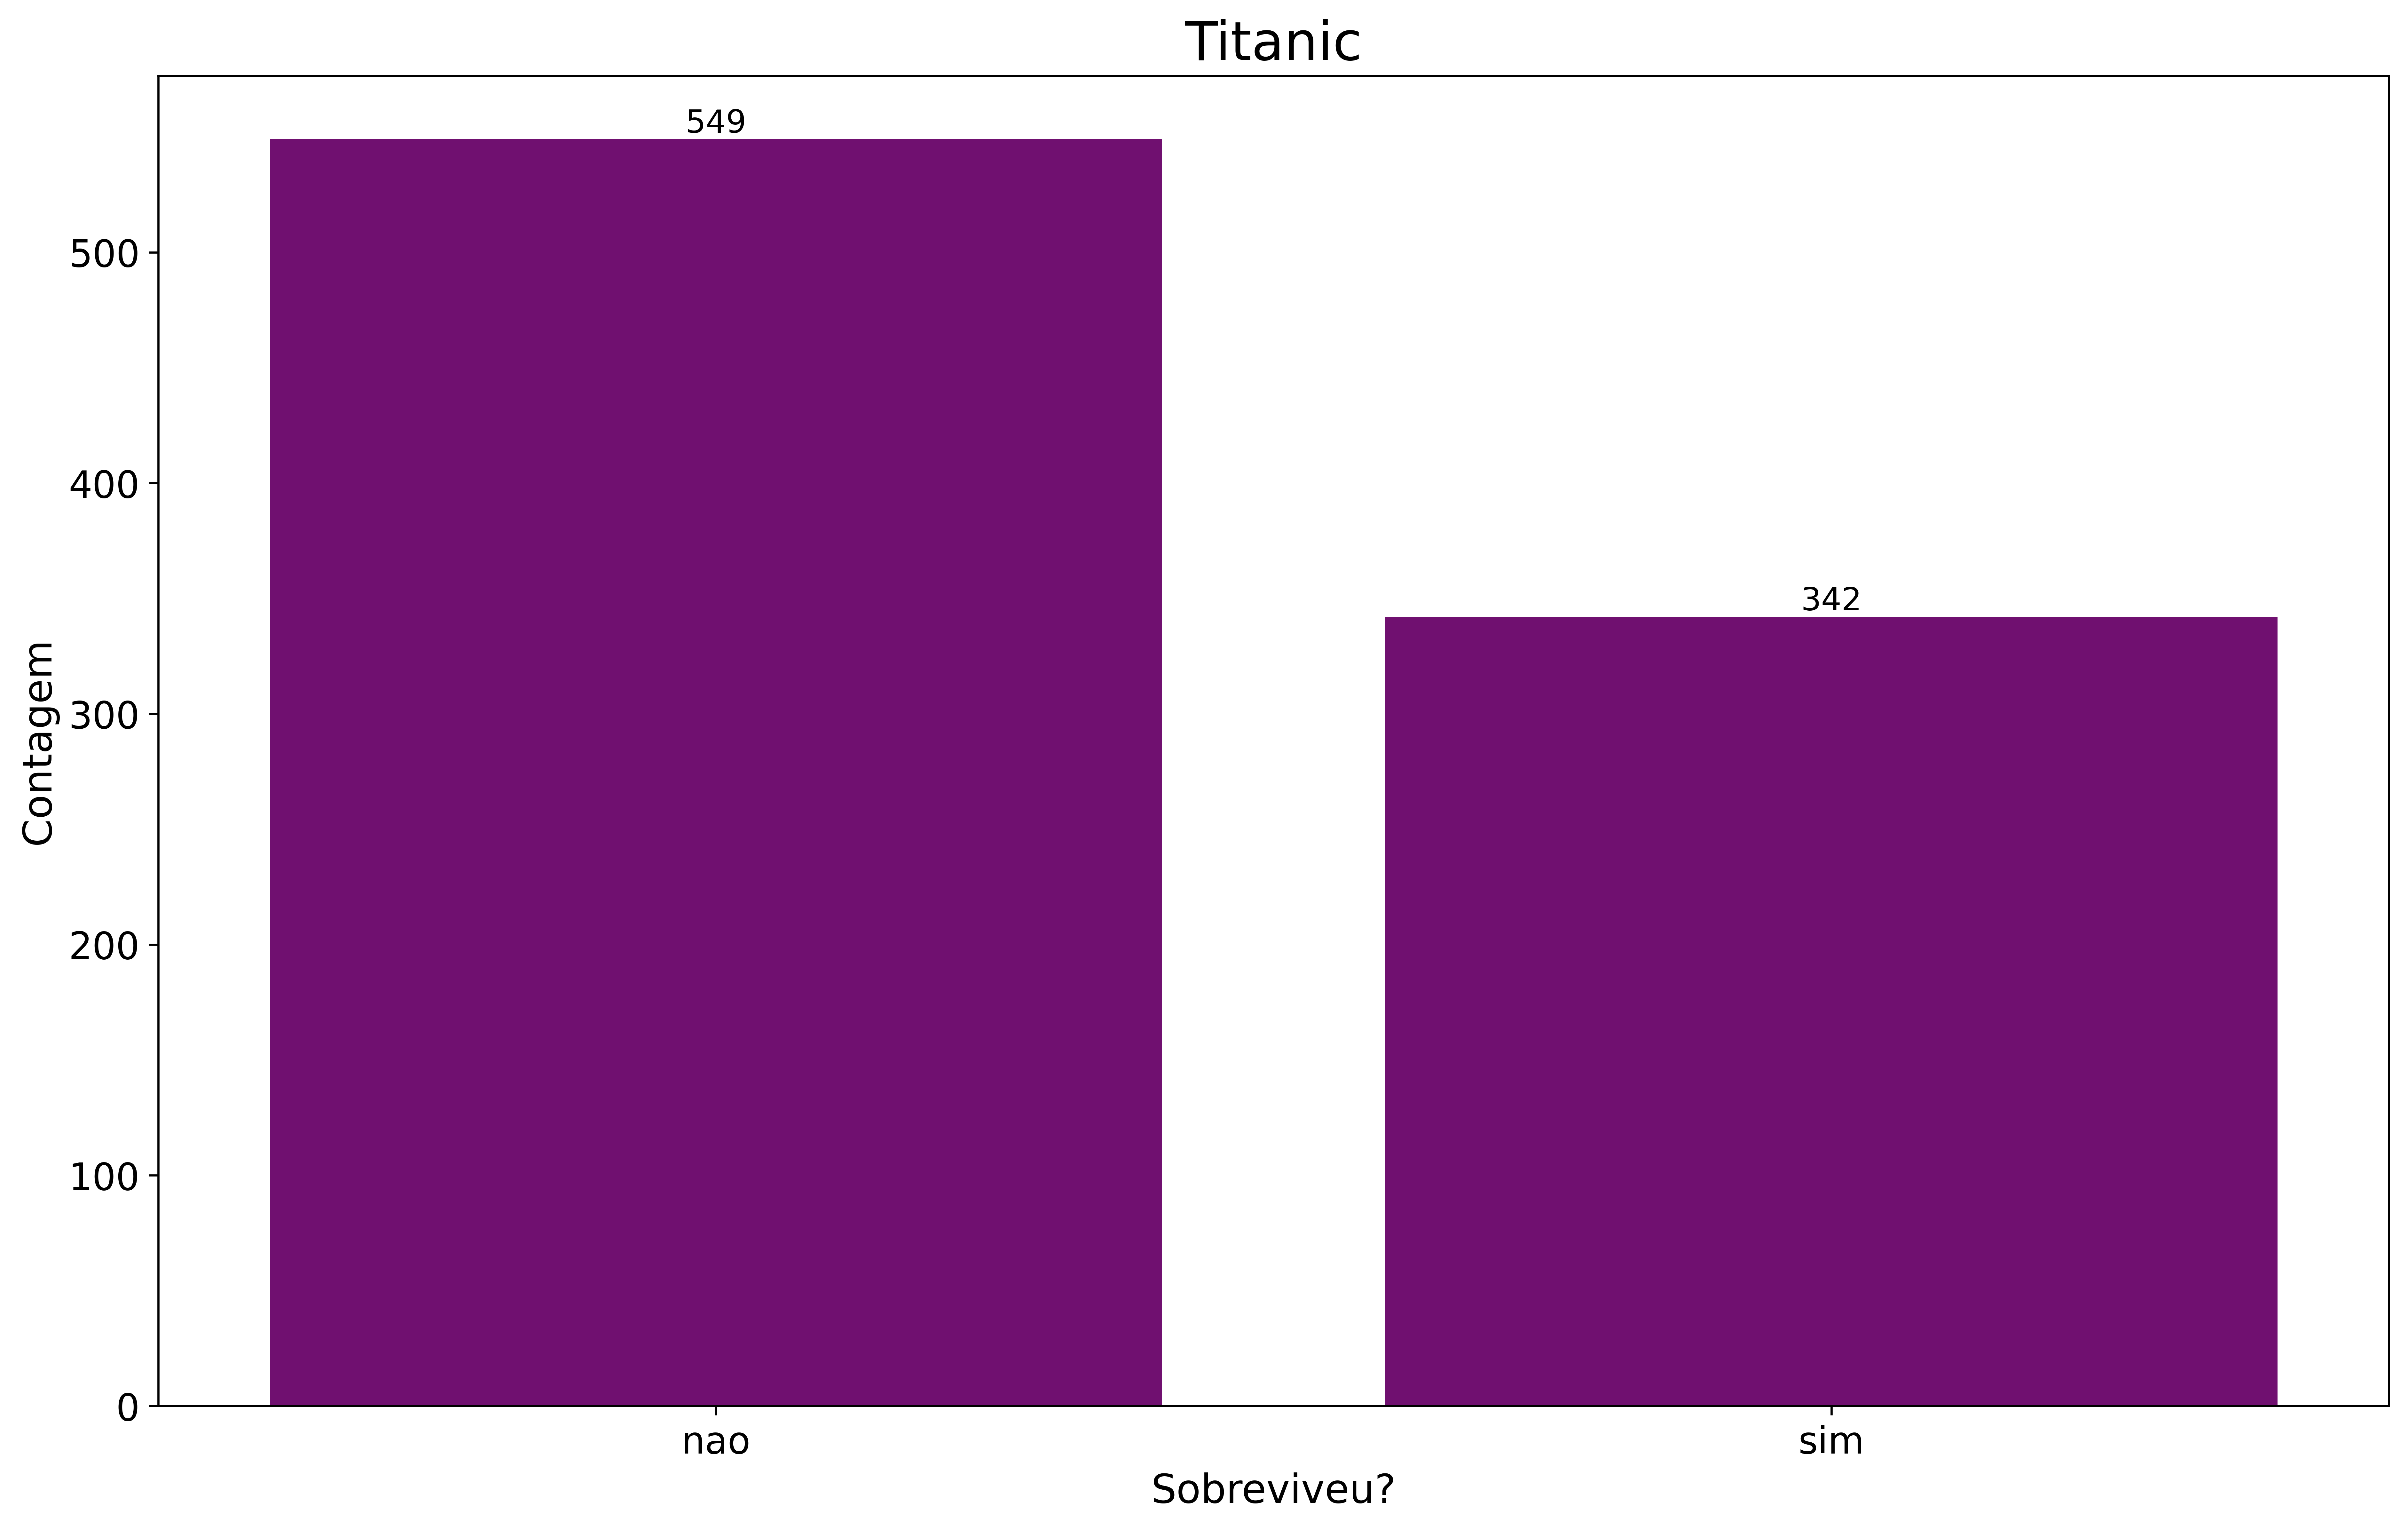

In [49]:
# Adicionando as contagens para melhorar a visualização
# da formatação do gráfico de cima só foi adcionado uma linha.
# Primeiro salva o gráfico no ax aonde vai ficar armazenado
# os valores nos containers, e dentro do ax busca o container,
# bar_label é o rotulo para as barras (valores)

plt.figure(figsize=(15,9), dpi=600)
ax = sns.countplot(data=titanic, x='sobreviveu', color='purple')
for container in ax.containers: ax.bar_label(container, fontsize=12)
plt.title('Titanic',fontsize=20)
plt.xlabel('Sobreviveu?',fontsize=15)
plt.ylabel('Contagem',fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
# colocou os rótulos que estavam dentro dos containers nas barras.

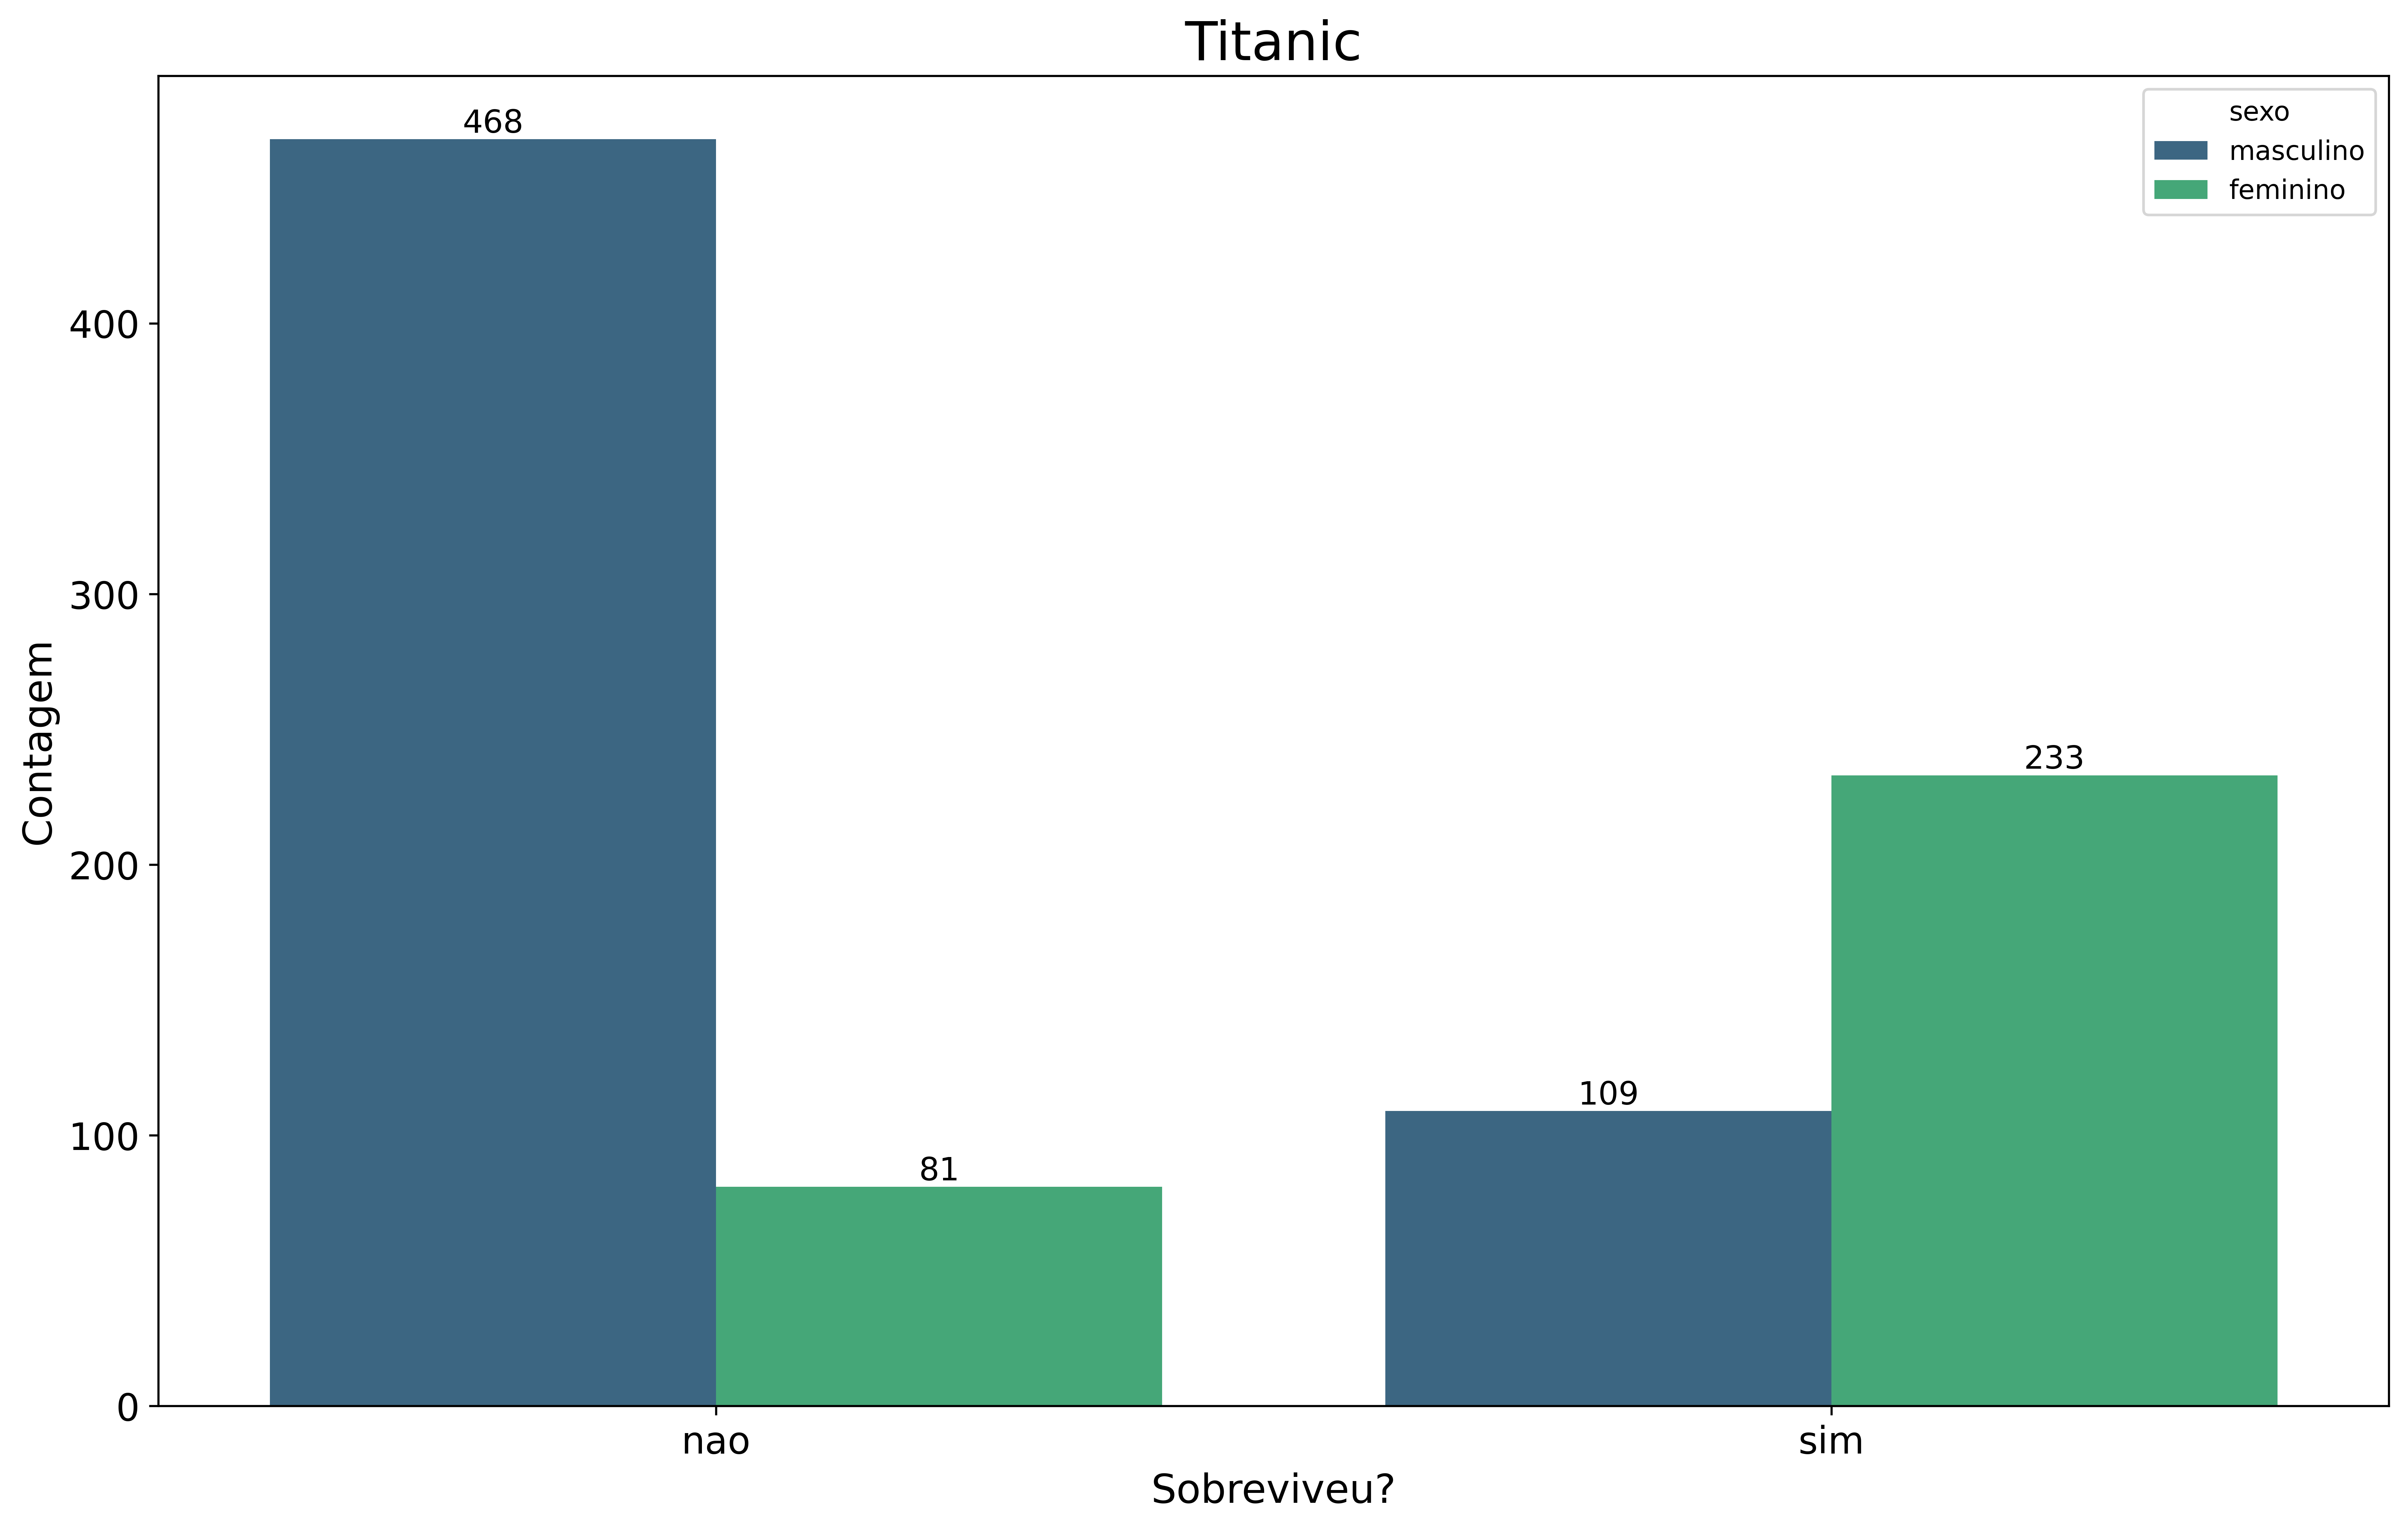

In [50]:
# Detalhando as informações entre grupos
# só adcionando um argumento que é o hue ( agrupa ) e a paleta de cor
# inserindo uma variável categórica no caso é sexo e a paleta de cor.

plt.figure(figsize=(15,9), dpi=600)
ax = sns.countplot(data=titanic, x='sobreviveu', hue='sexo', palette='viridis', legend=True)
for container in ax.containers: ax.bar_label(container, fontsize=12)
plt.title('Titanic',fontsize=20)
plt.xlabel('Sobreviveu?',fontsize=15)
plt.ylabel('Contagem',fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()



In [51]:
# Gráfico de barras geral

# Valor médio da tarifa em cada local de embarque
# guardei no objeto dados uma descritiva.
# groupby tem critério qualitativo,
#logo agrupei na variável qualitativa que no caso é embarque
# a media é da variável quantitativa no caso valor_tarifa.
dados = titanic[['embarque', 'valor_tarifa']].groupby(by=['embarque']).mean()
dados

# valor médio das tarifas nos pontos de embarque

,valor_tarifa
embarque,
Cherbourg,59.954144
Queenstown,13.276030
Southampton,27.079812


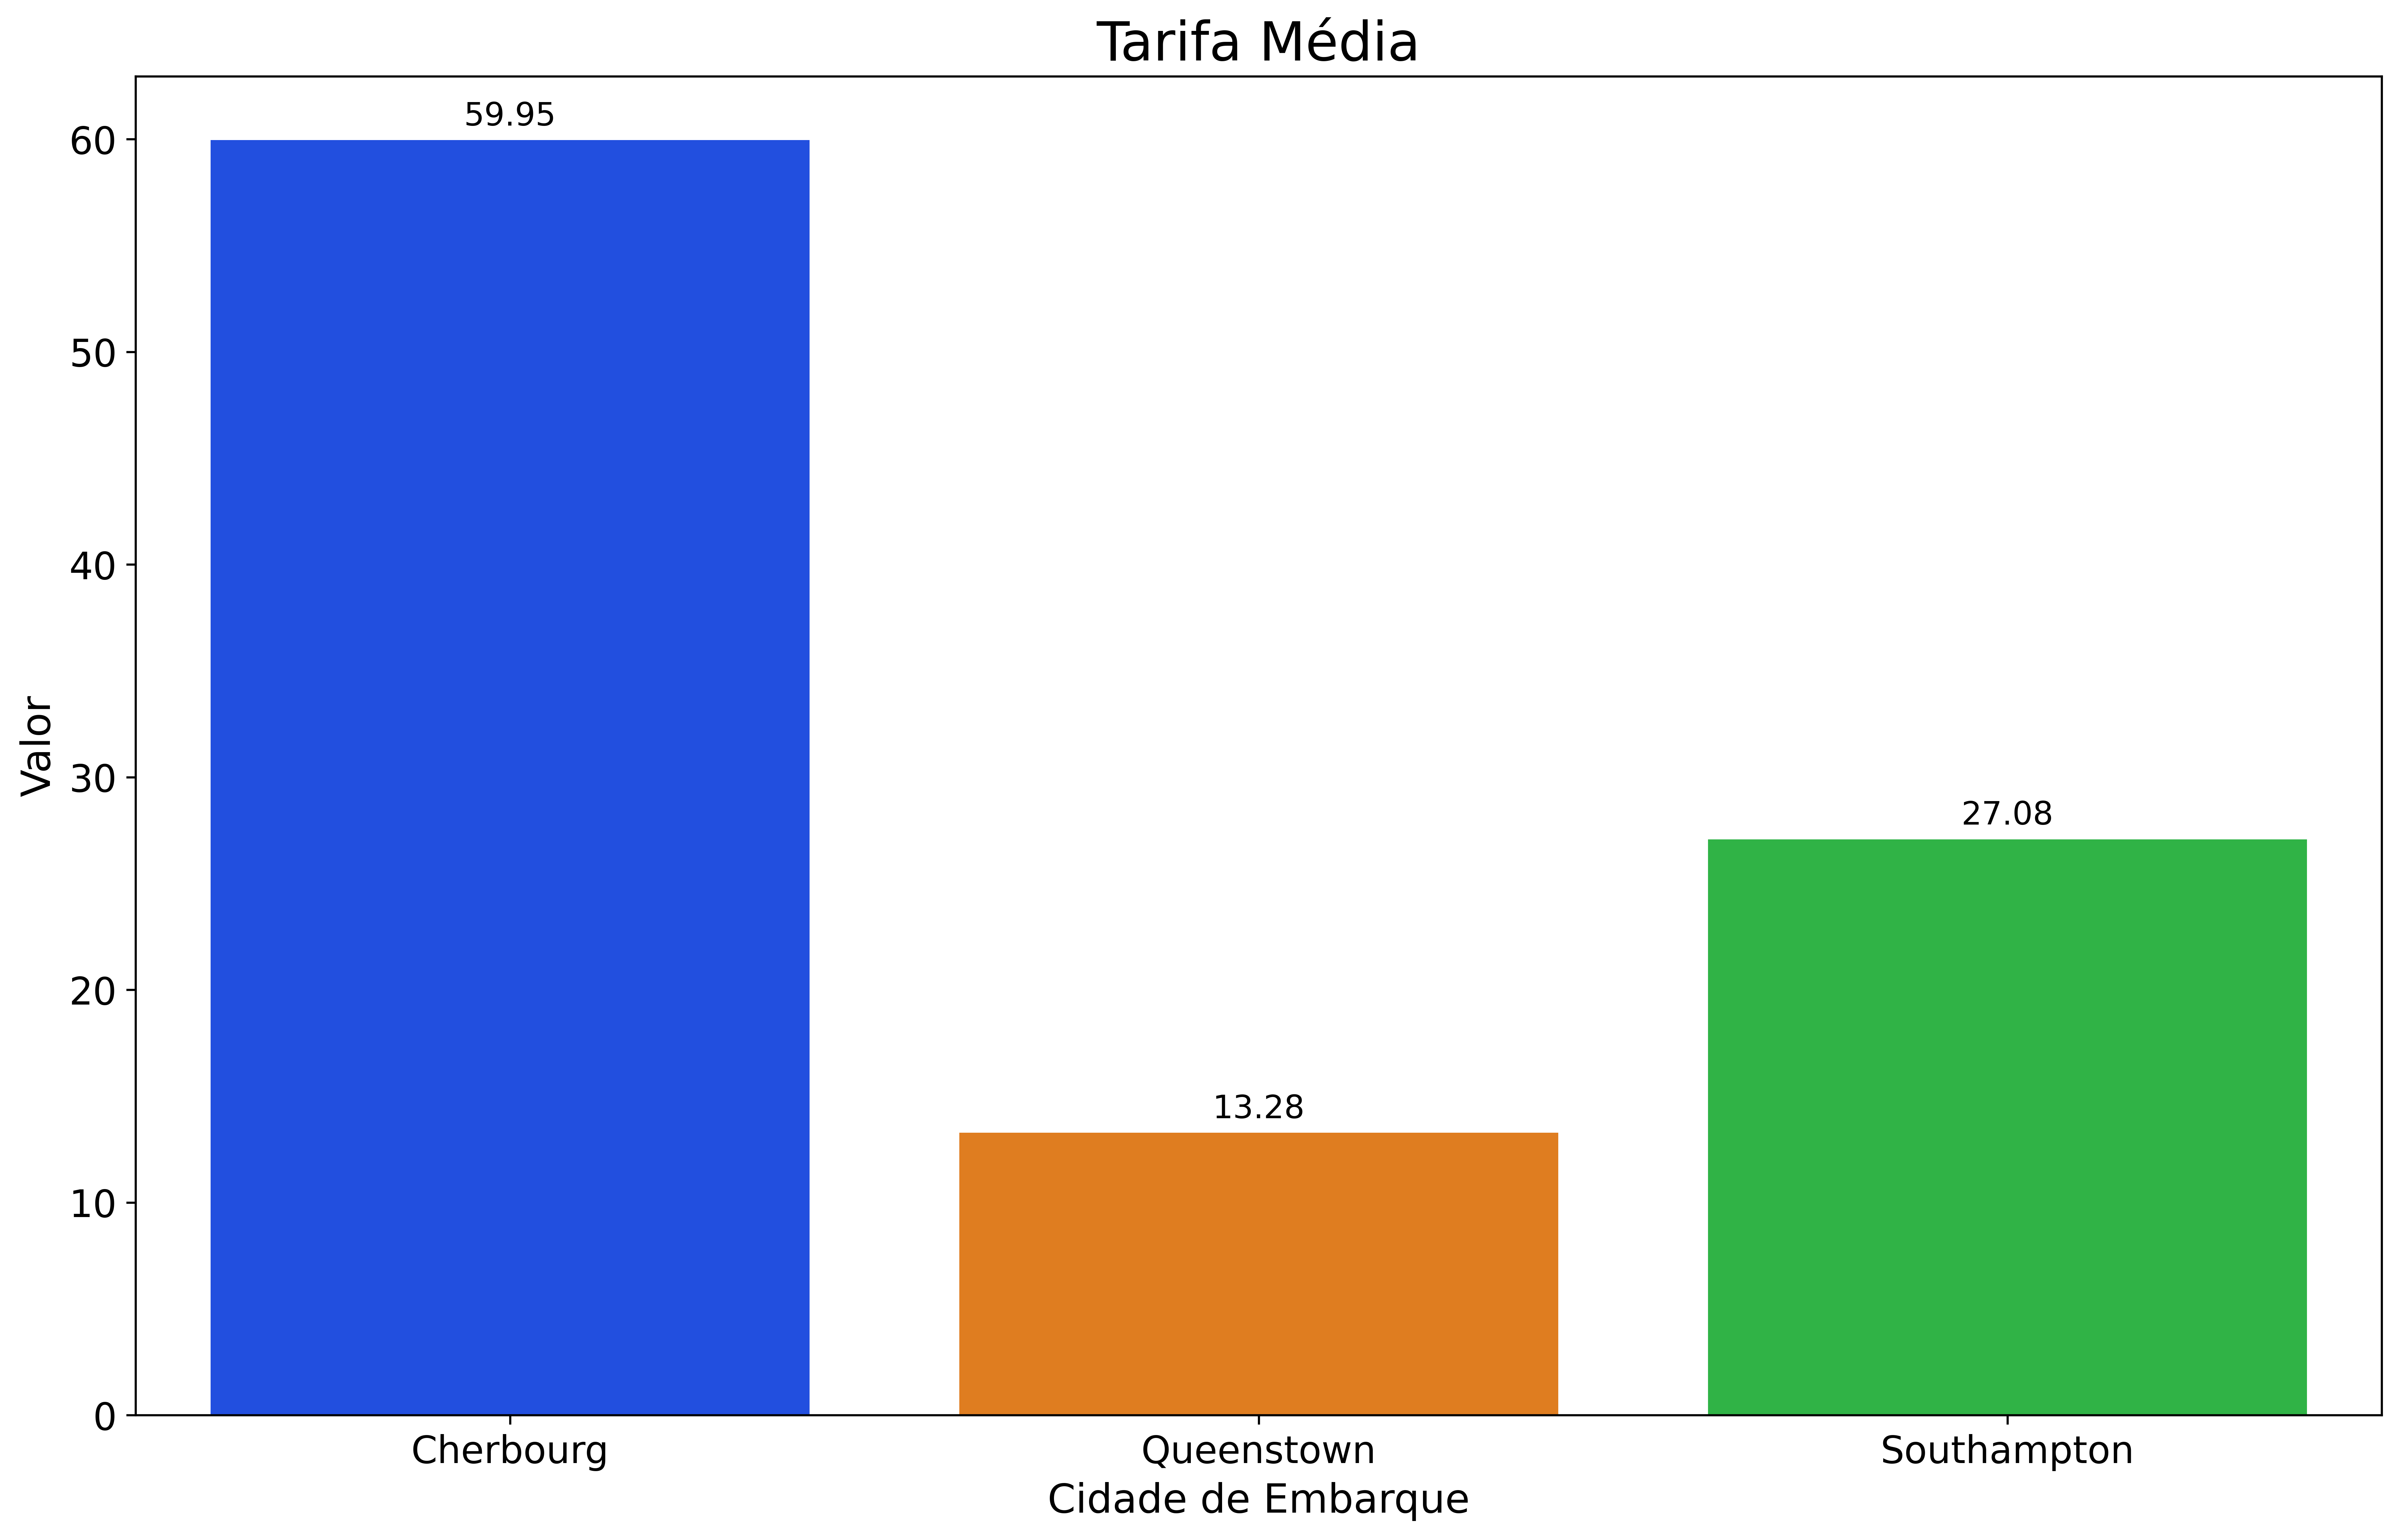

In [52]:
# Gerando o gráfico de barras
# barplot grafico de barras em geral
# padding é posição da barra, fmt="%.2f" vai plotar só 2 casas decimais
# dados.index o embarque não mais uma variável e sim indíce
#hue=dados.index, palette='bright'(as barras ficaram cada um de uma cor)
plt.figure(figsize=(15,9), dpi=600)
ax1 = sns.barplot(data=dados, x=dados.index, y='valor_tarifa', hue=dados.index, palette='bright')
for container in ax1.containers: ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=12)
plt.title("Tarifa Média",fontsize=20)
plt.xlabel('Cidade de Embarque',fontsize=15)
plt.ylabel('Valor',fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

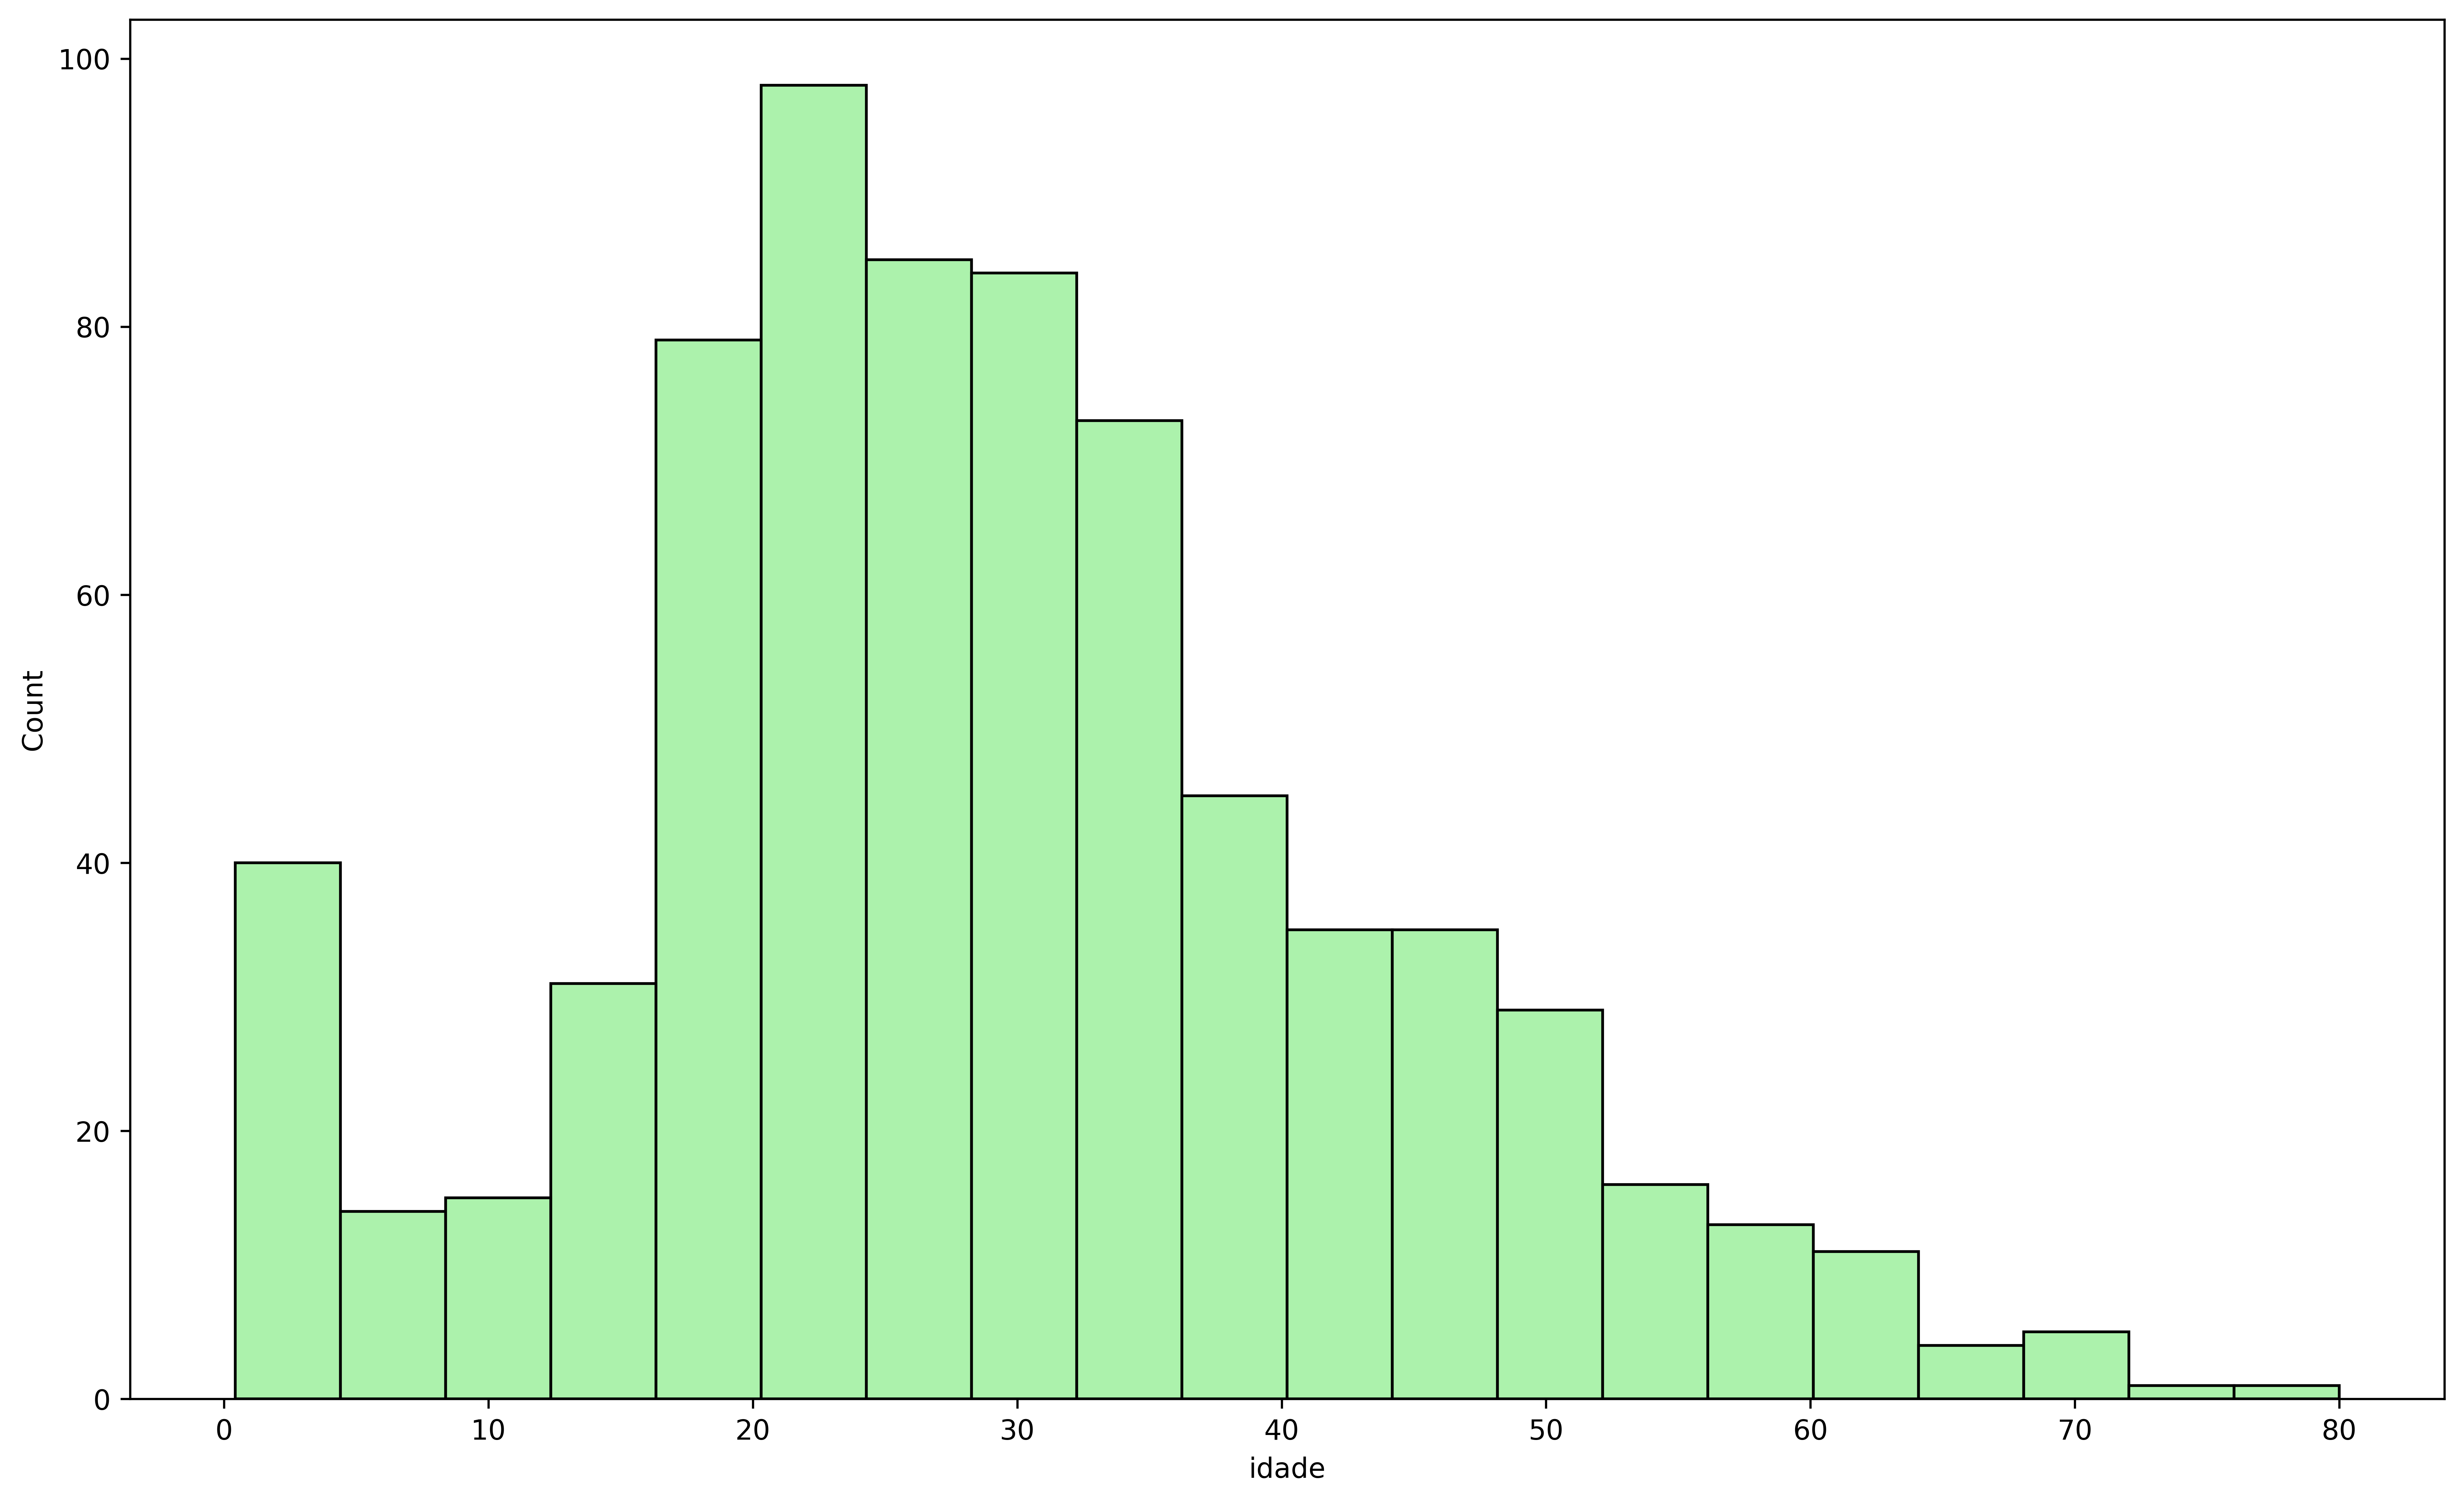

In [53]:
# Histograma
# gráfico que representa a distribuição de uma variável métrica
# Vamos elaborar o histograma da idade, ou seja, variável métrica
# histplot-barras juntas mostra
# como estão distribuidas os valores das variáveis.


plt.figure(figsize=(15,9), dpi=600)
sns.histplot(data=titanic, x='idade', color='lightgreen')
plt.show()



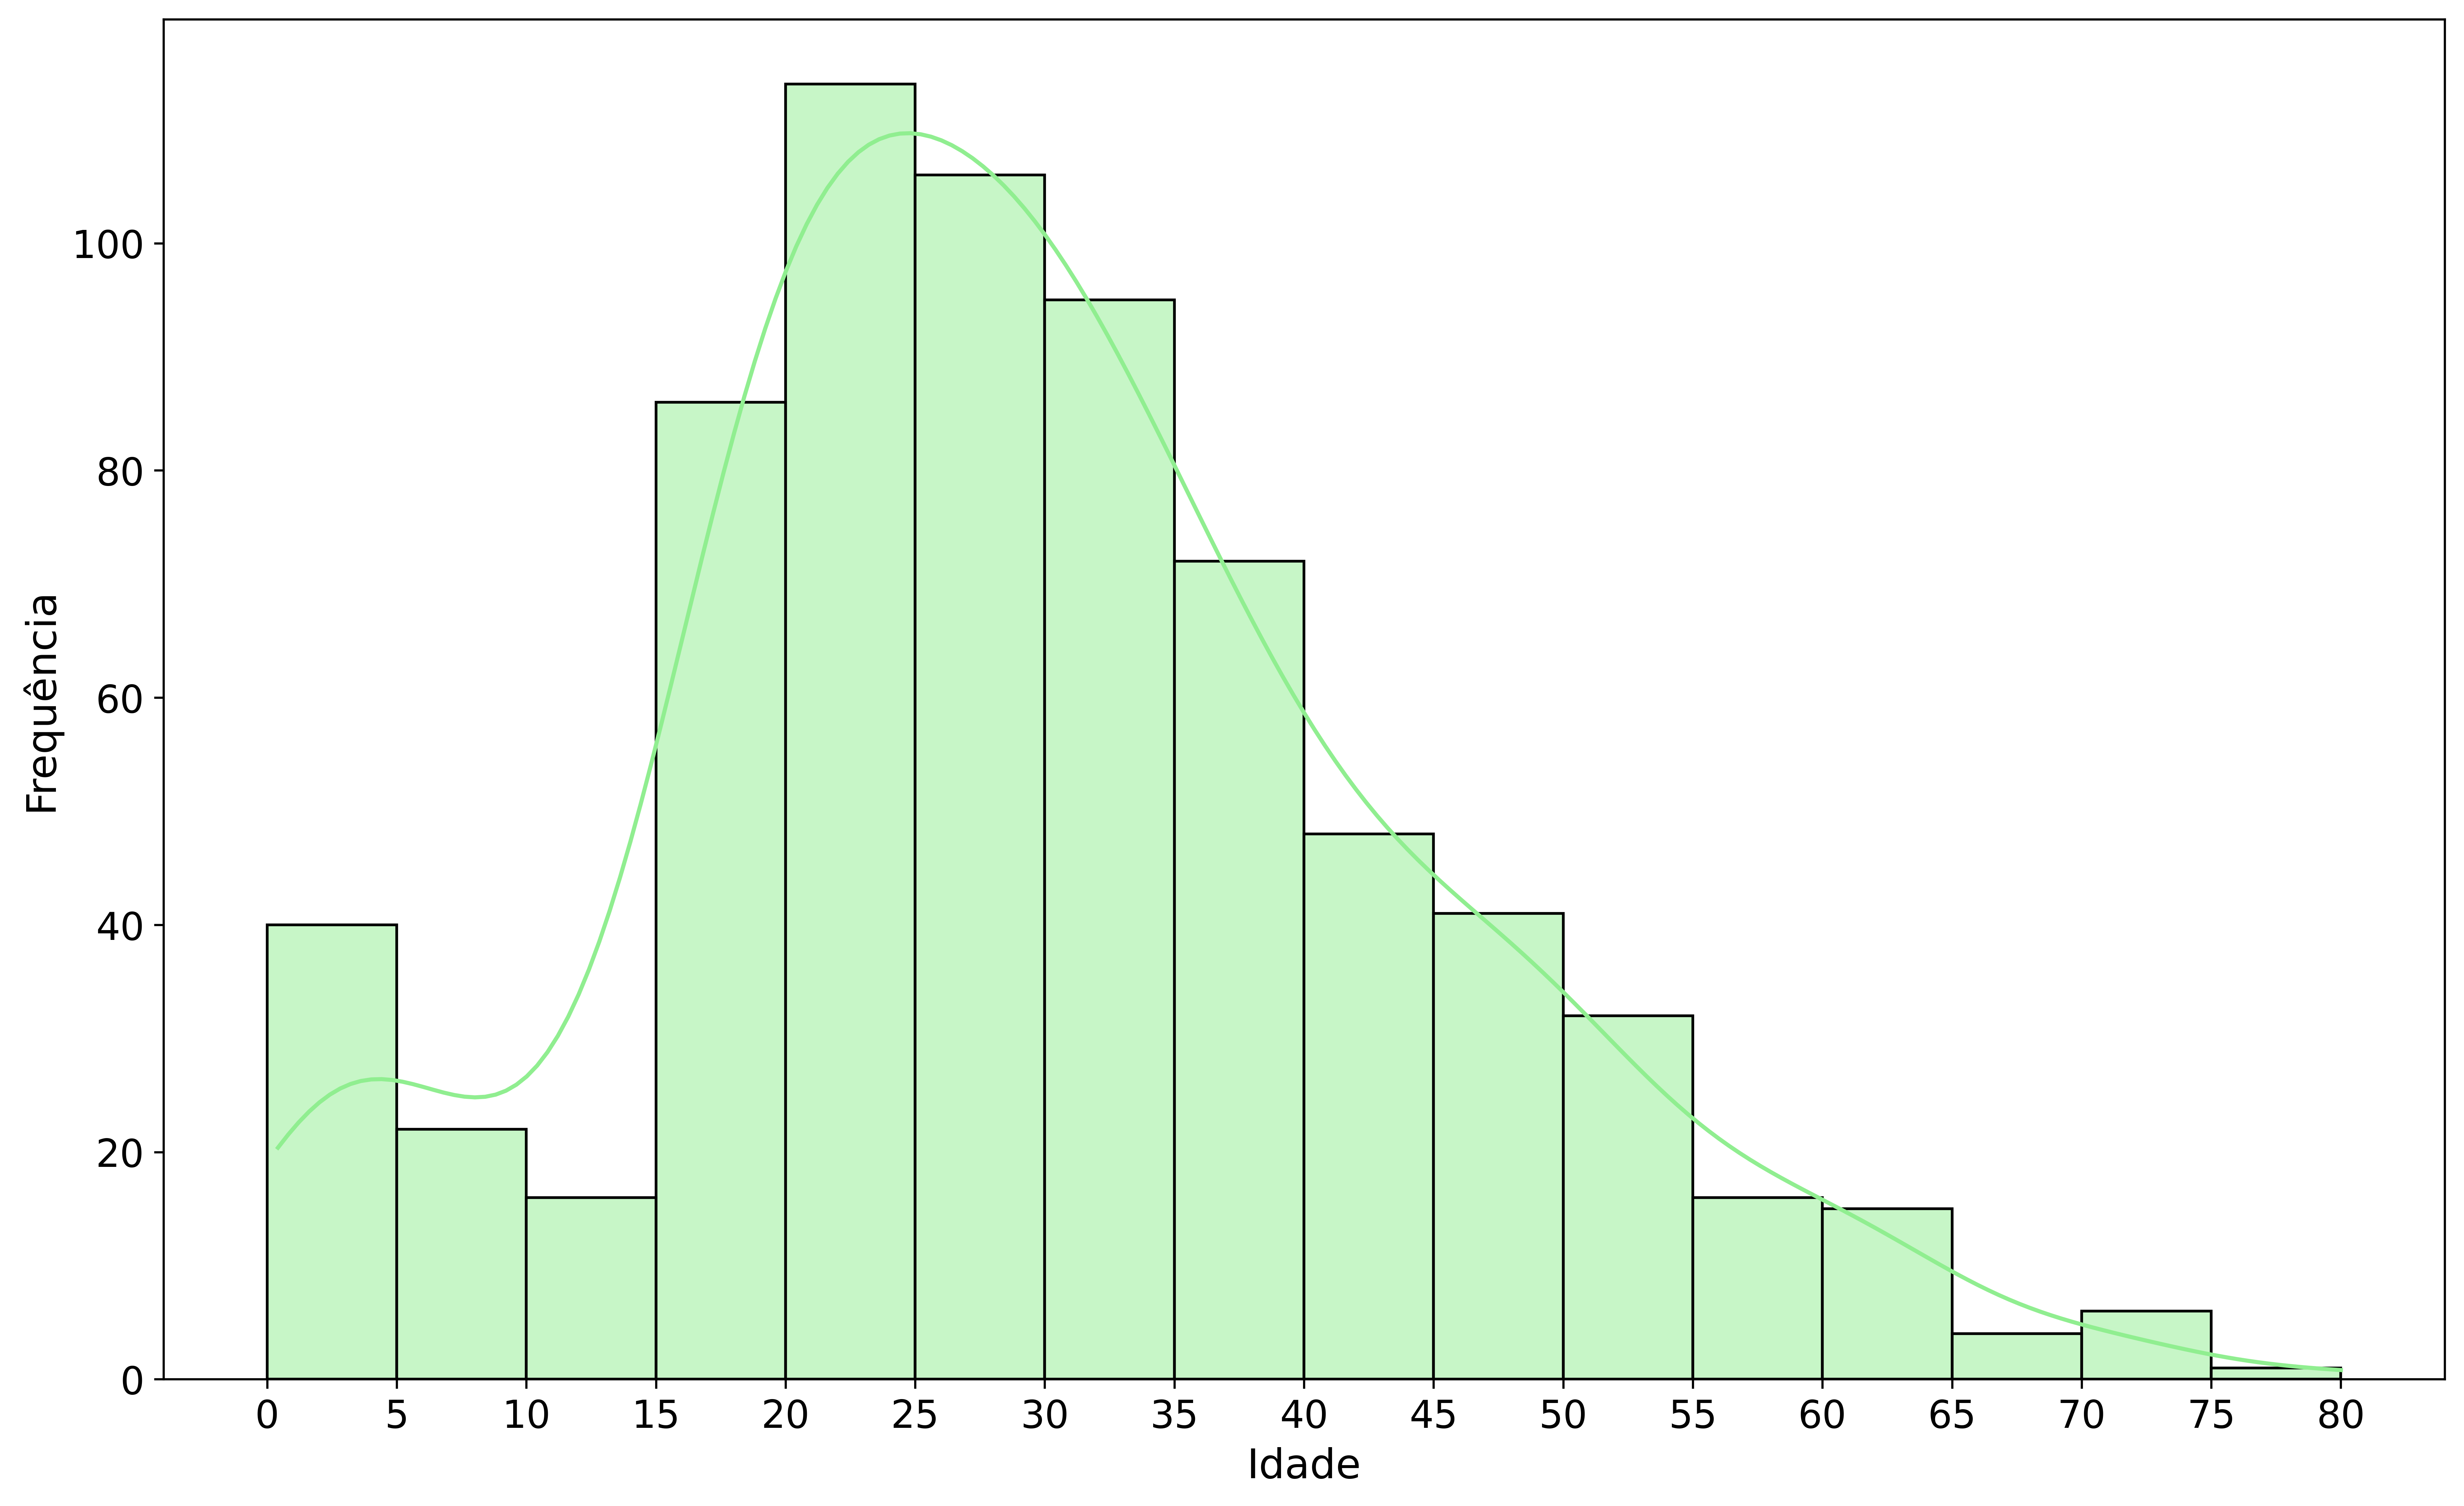

In [54]:
# Aprimorando a apresentação do gráfico
# adcionando formatações nos eixos.
# O argumento bins=range forma uma sequência,
# no caso esta de 0 a 85 variando de 5 em 5   bins=range(0,85,5).
# idade máxima até 80, mas preciso de um pouco a mais até 85.
# kde plota uma curva suave da densidade da distribuição dos dados.

plt.figure(figsize=(15,9), dpi=600)
sns.histplot(data=titanic, x='idade', bins=range(0,85,5), kde=True, color='lightgreen')
plt.xlabel('Idade',fontsize=15)
plt.ylabel('Frequência',fontsize=15)
plt.xticks(ticks=np.arange(0,85,5), fontsize=14)
plt.yticks(fontsize=14)
plt.show()

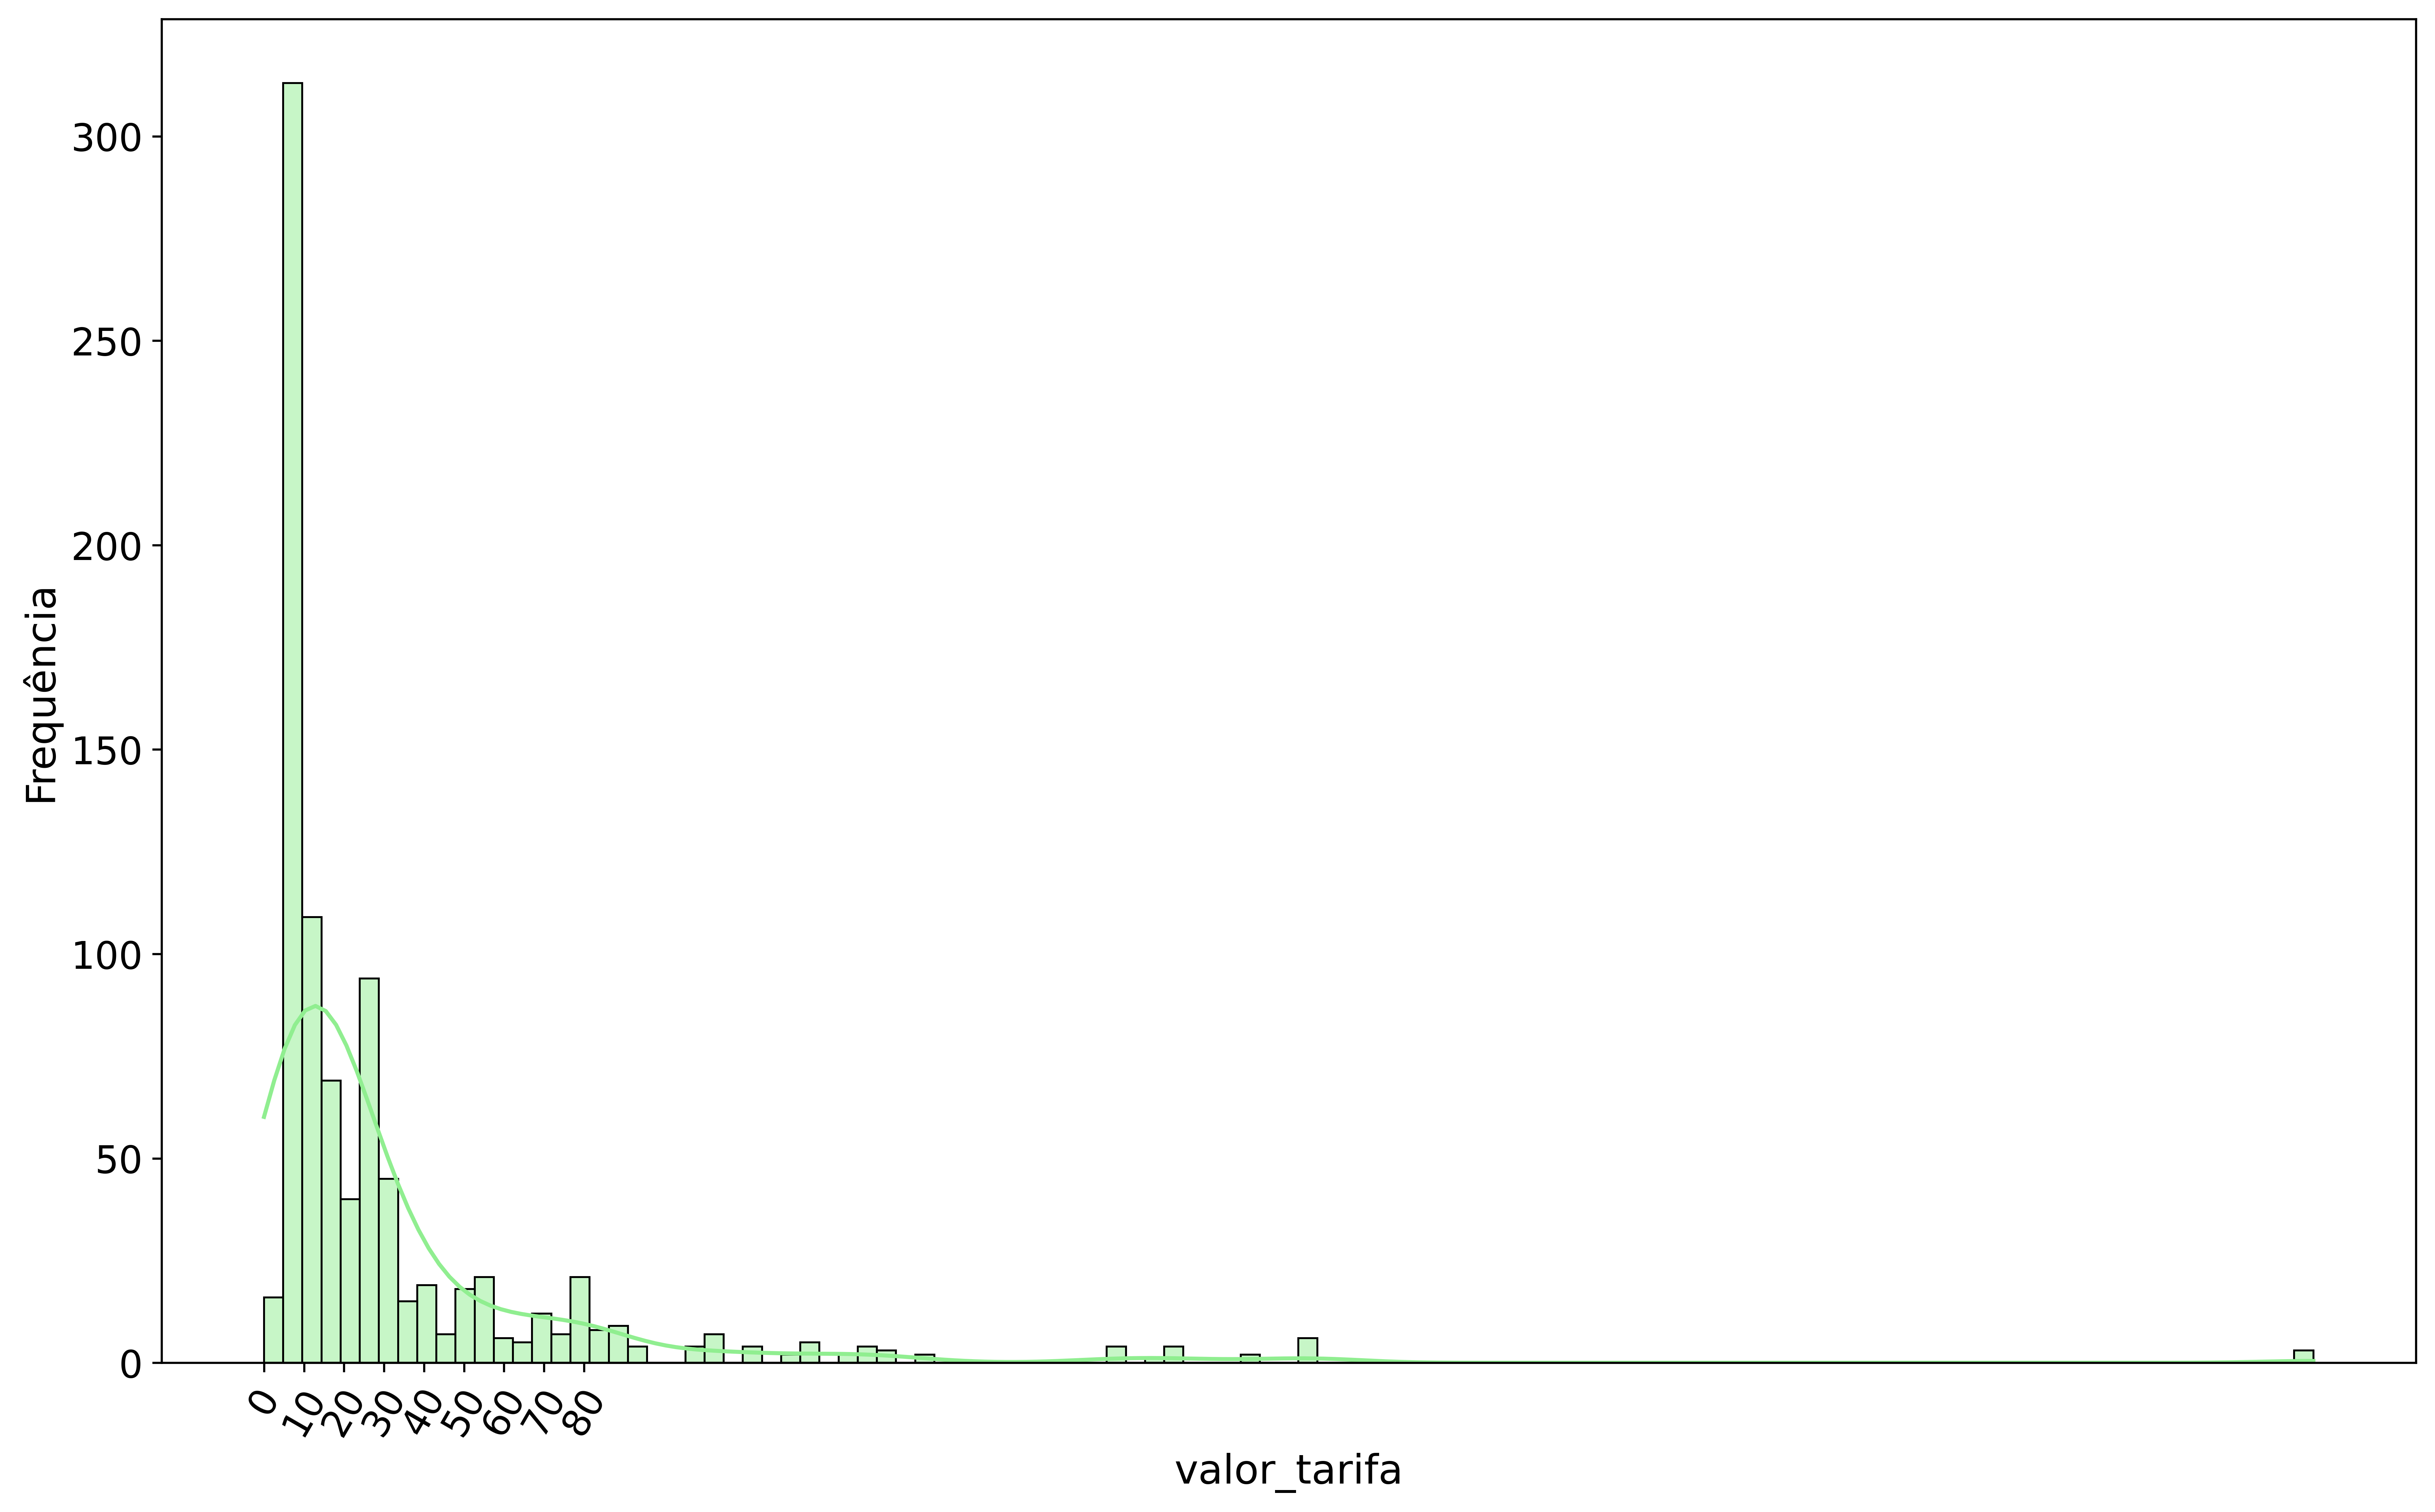

In [55]:
plt.figure(figsize=(15,9), dpi=600)
sns.histplot(data=titanic, x='valor_tarifa', kde=True, color='lightgreen')
plt.xlabel('valor_tarifa',fontsize=15)
plt.ylabel('Frequência',fontsize=15)
plt.xticks(ticks=np.arange(0,85,10),rotation=60, fontsize=14)
plt.yticks(fontsize=14)
plt.show()

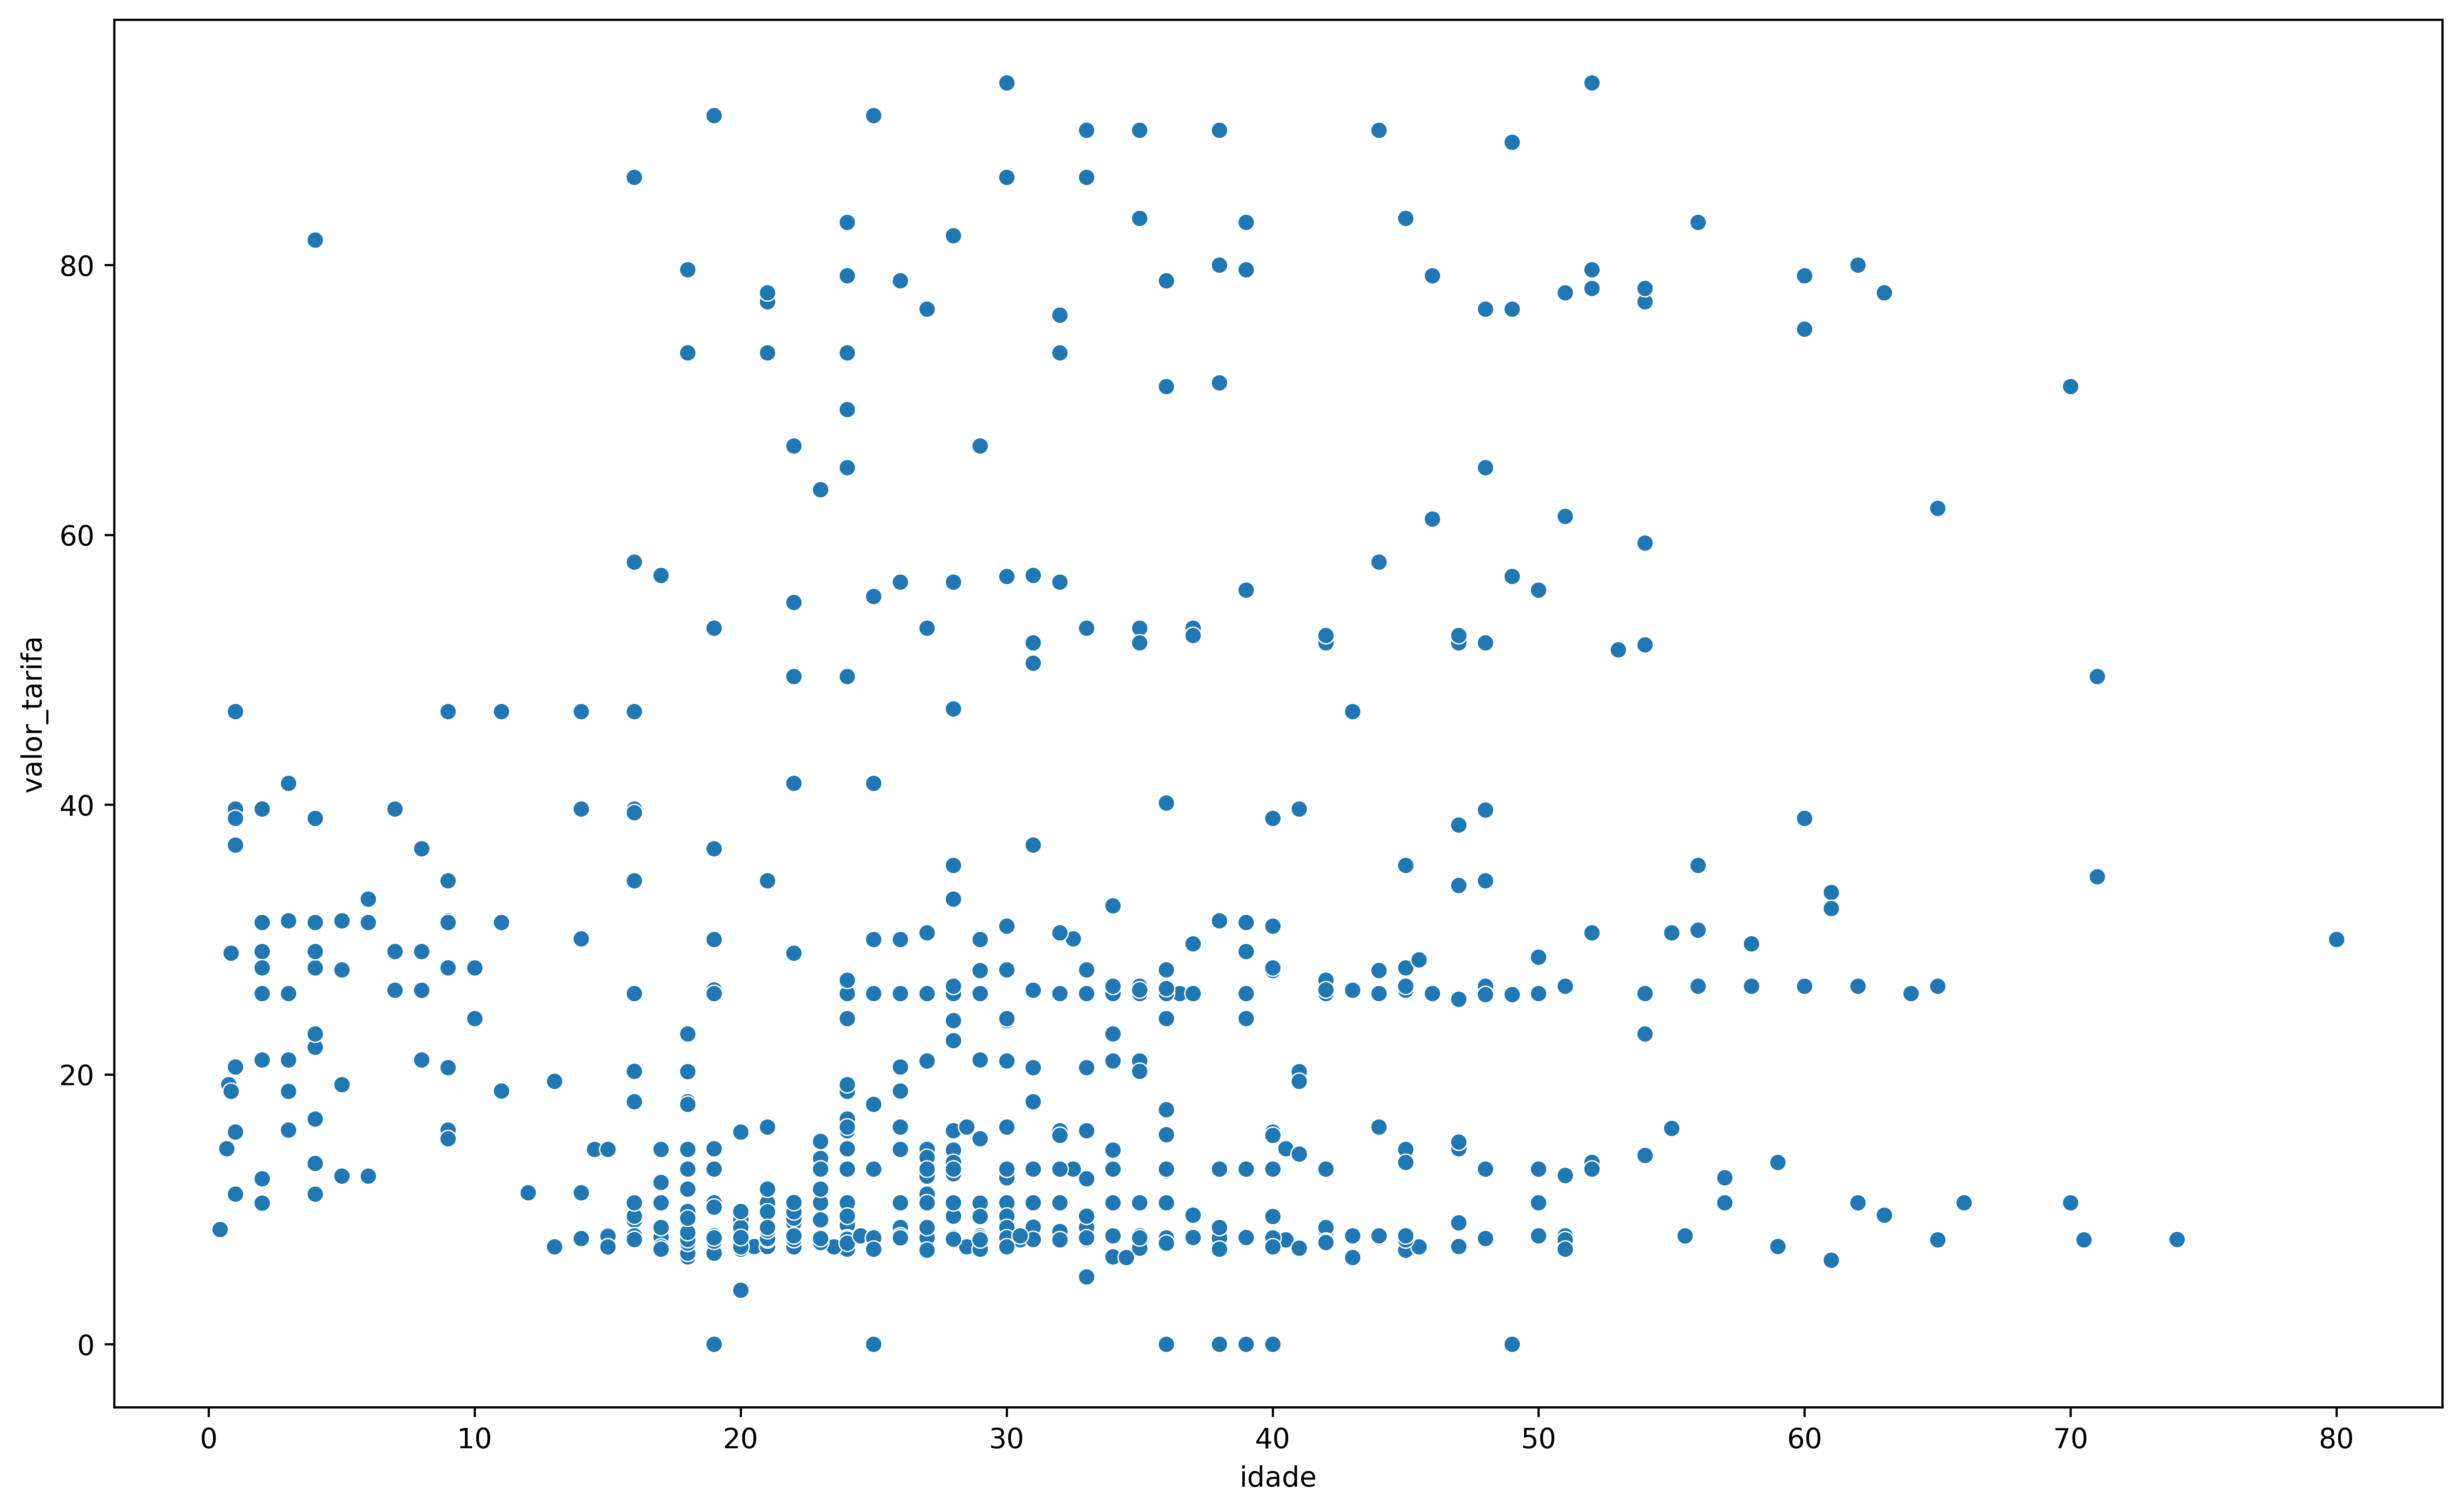

In [56]:
#Gráfico de pontos (scatterplot) ou gráfico de dispersão
# aonde vai representar duas variáveis métricas
# uma no eixo X e outra no eixo y
# cada observação da amostra vai ser representada
# por um pontinho do gráfico
# Vamos elaborar um gráfico de dispersão dos pontos
# Neste caso, devemos especificar as variáveis métricas dos eixos x e y

# Suponha que o objetivo seja analisar passageiros que pagaram menos de $100

plt.figure(figsize=(15,9), dpi=600)
sns.scatterplot(data=titanic[titanic['valor_tarifa']<100], x='idade', y='valor_tarifa')
plt.show()


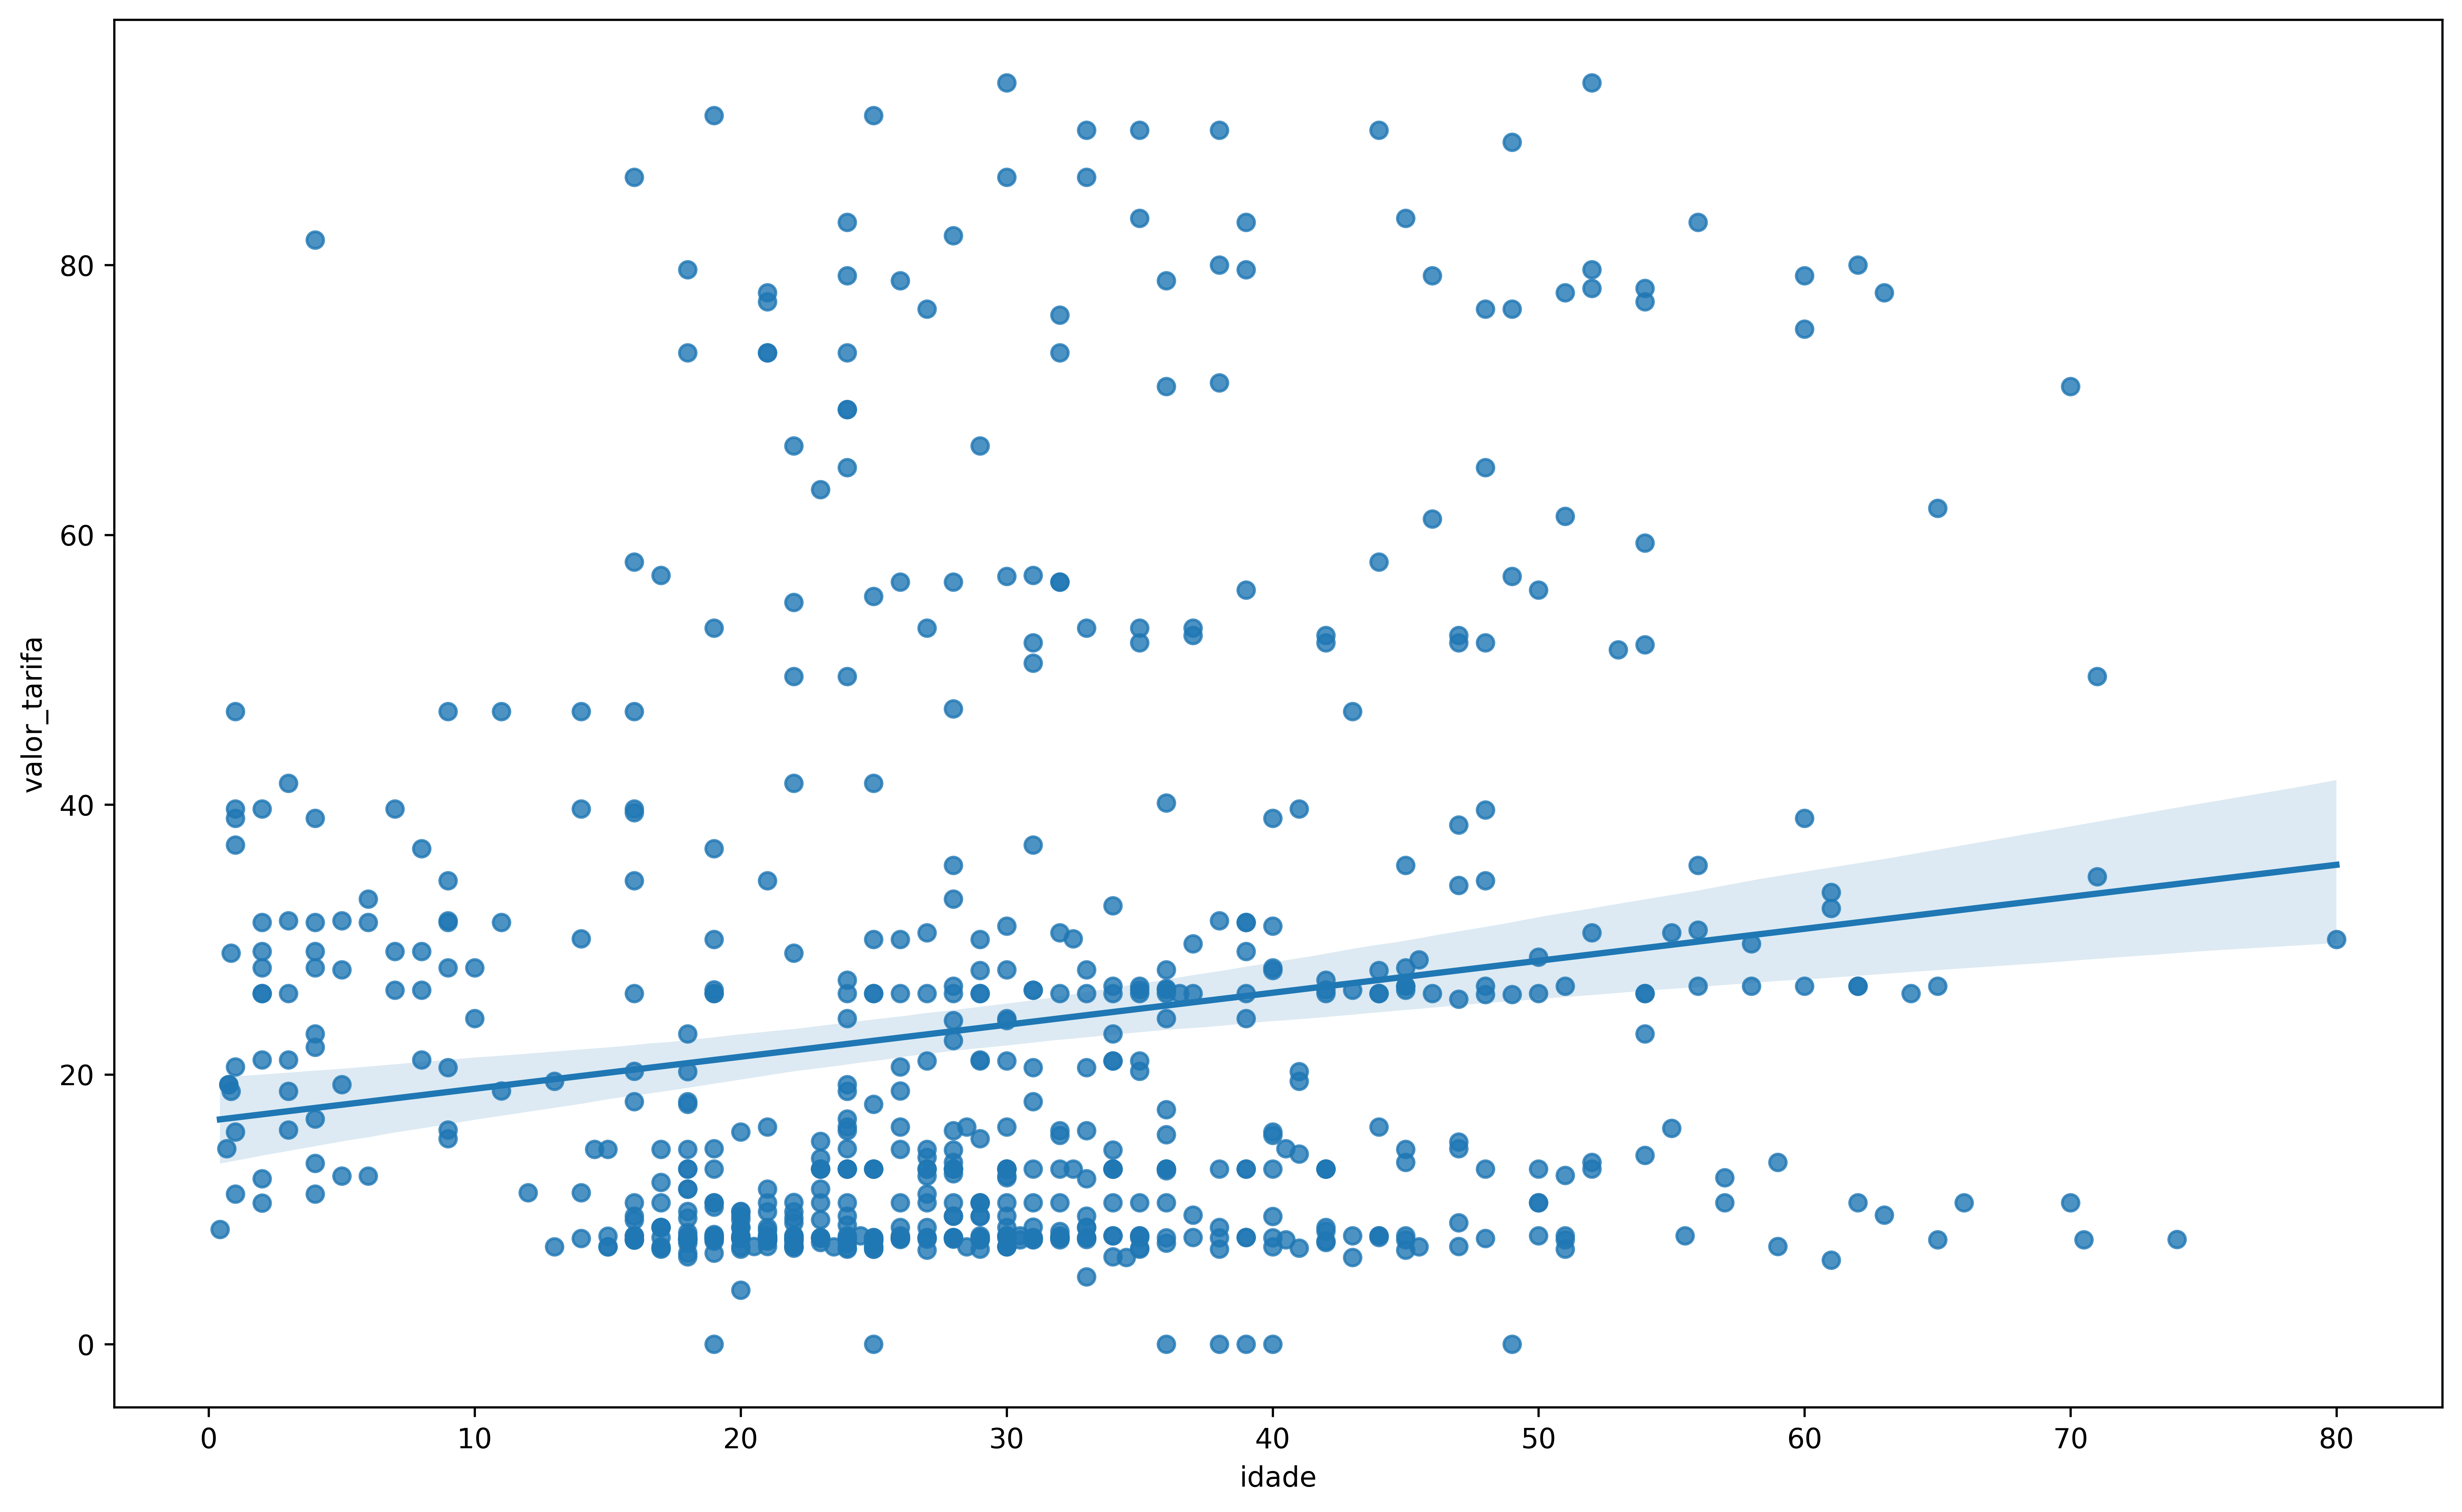

In [57]:
 #Existe alguma relação entre as variáveis?
 #neste caso troco scartteplot por regplot

plt.figure(figsize=(15,9), dpi=600)
sns.regplot(data=titanic[titanic['valor_tarifa']<100], x='idade', y='valor_tarifa')
plt.show()

# regplot-adciona ajuste linear à nuvem de pontos
# mostrando que existe uma relação entre a
# idade e o valor da tarifa, mas a inclinação não esta muito acentuada,
# então a relação é pequena.
# Quanto mais horizontal menor a relçaõ entre as variáveis métricas,
# ou seja,
# quanto mais inclinada maior a relação positiva ou negativa das variáveis.

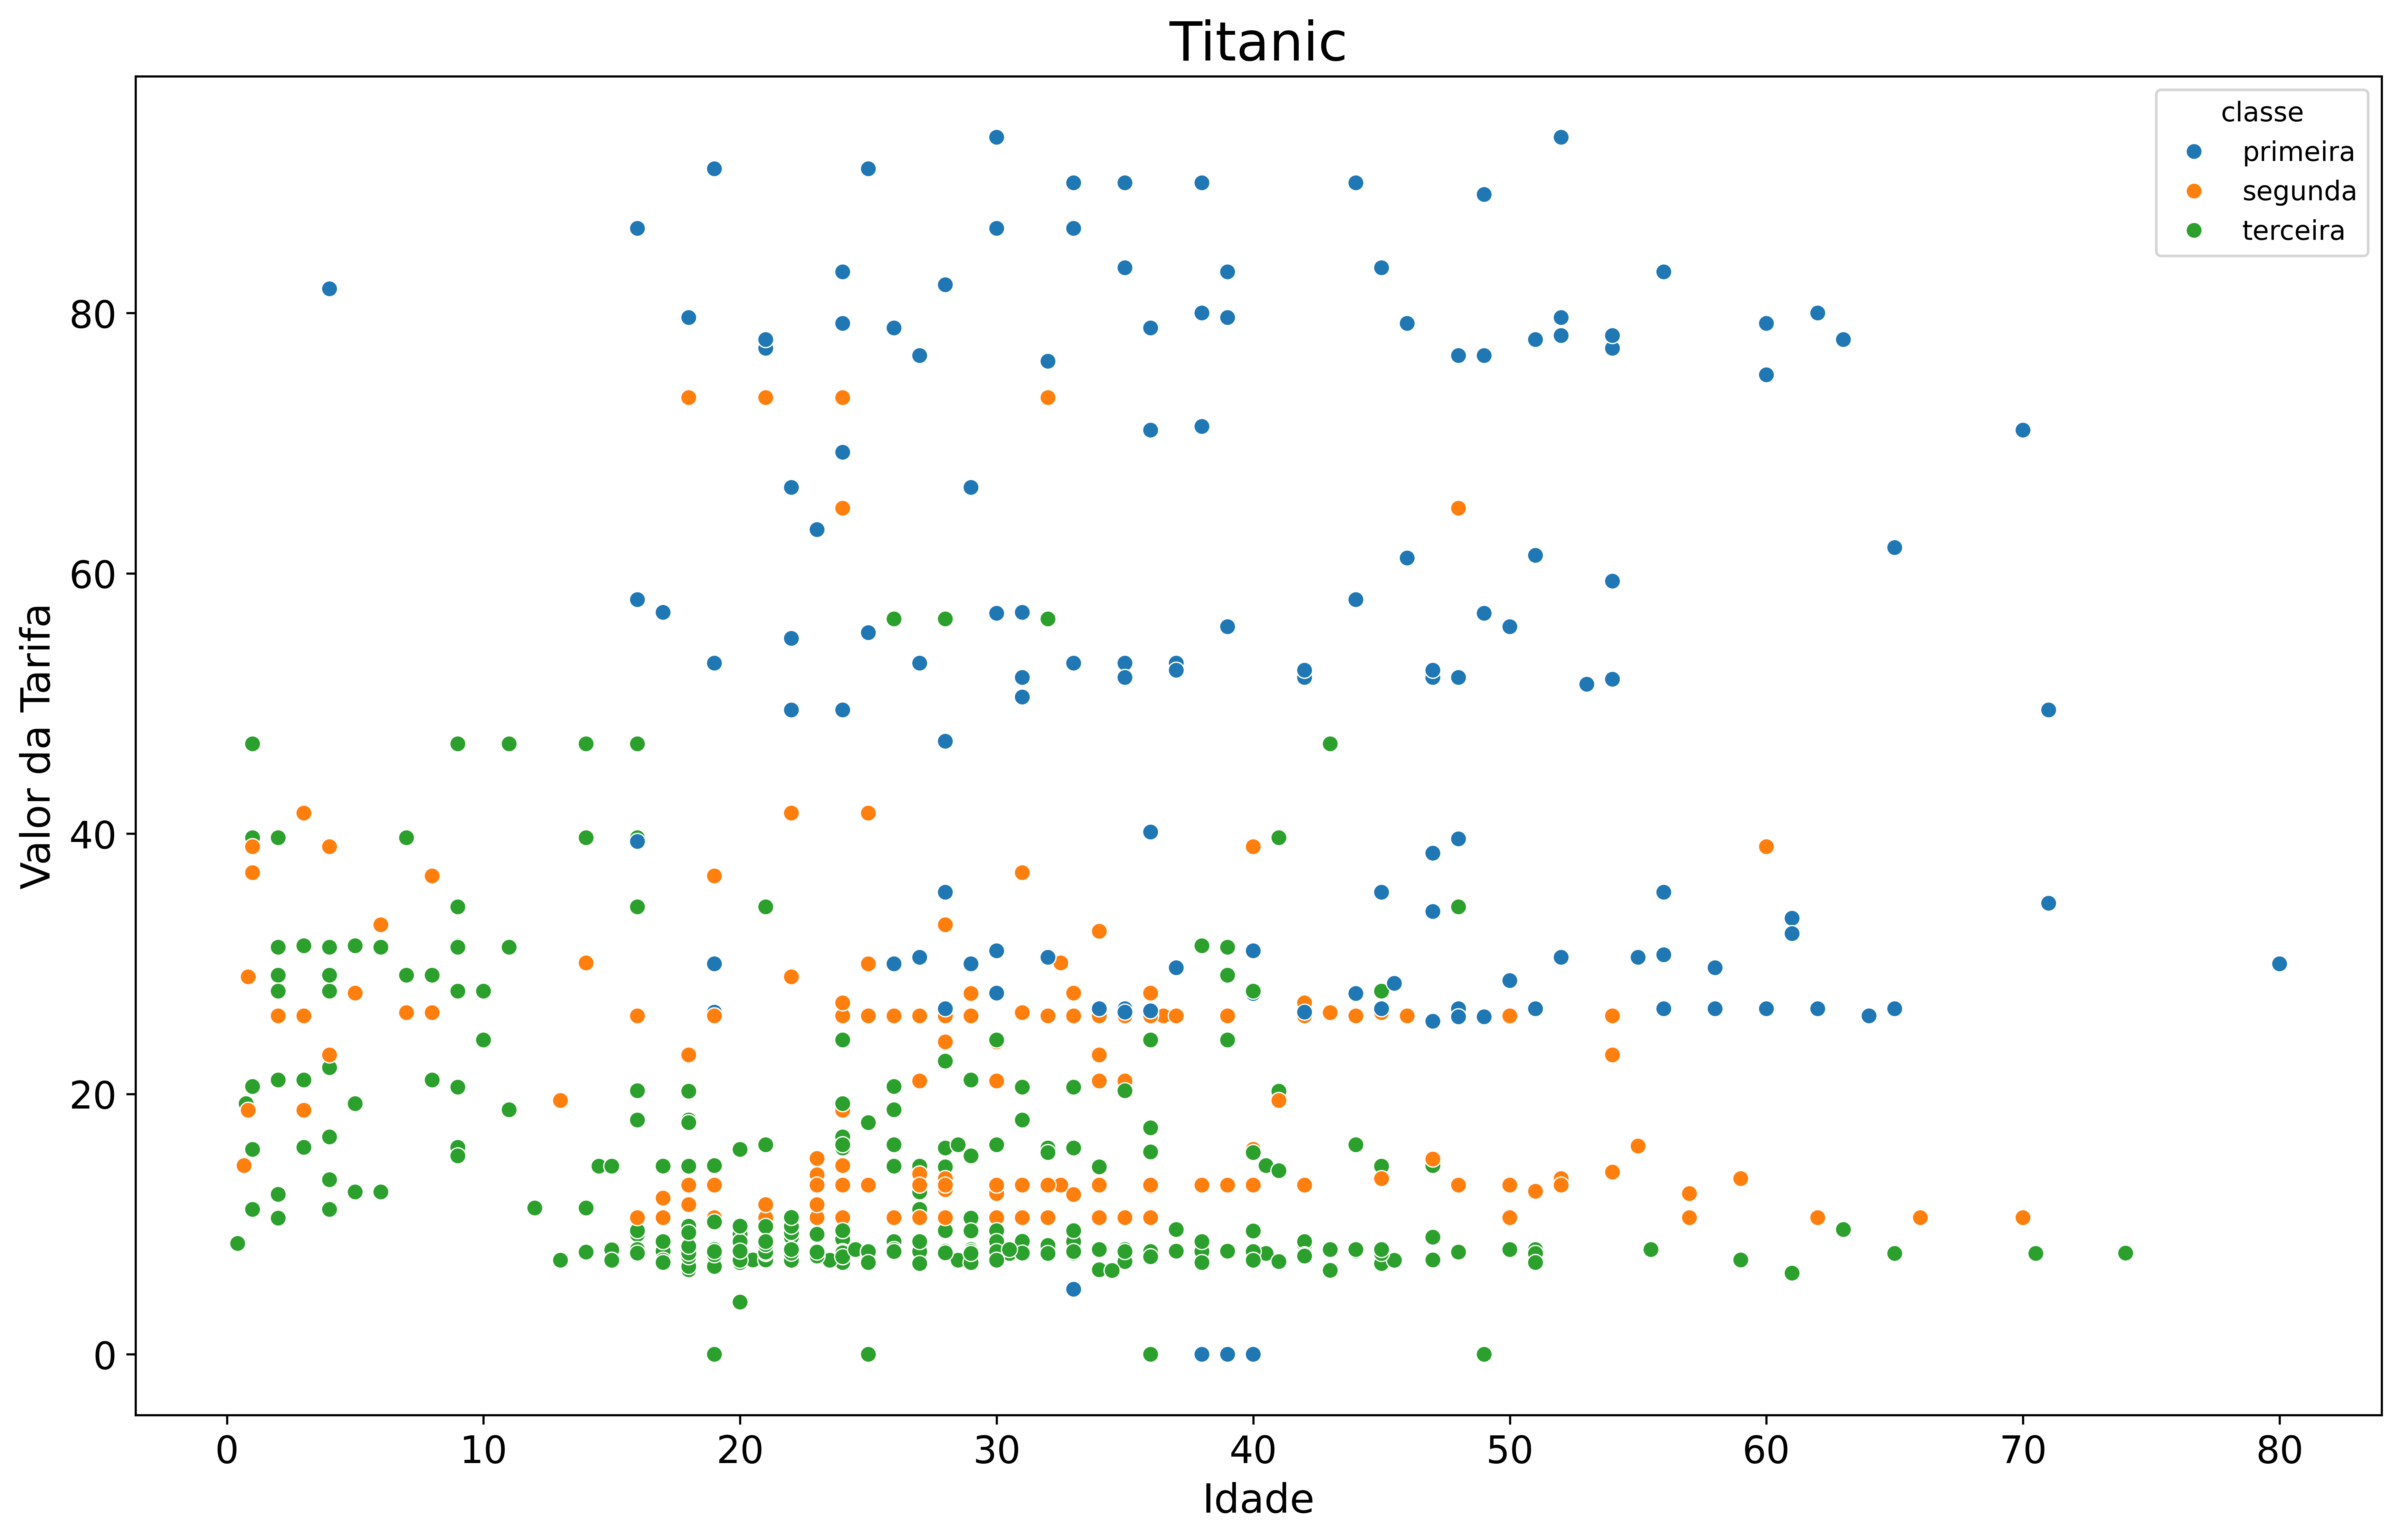

In [58]:
#Como há variáveis nos dois eixos, podemos adicionar outras variáveis:

# usei o hue para adcionar através das
# cores dos pontos a classe que é uma variável categórica,
# hue_order para deixar as categorias da classe na ordem de primeira, segunda e terceira classe.

plt.figure(figsize=(15,9), dpi=600)
sns.scatterplot(data=titanic[titanic['valor_tarifa']<100], x='idade', y='valor_tarifa',
                hue='classe', hue_order=['primeira', 'segunda', 'terceira'])
plt.title('Titanic',fontsize=20)
plt.xlabel('Idade',fontsize=15)
plt.ylabel('Valor da Tarifa',fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()



In [59]:
# Gráfico de linhas
# para representar os dados ao longo do tempo
# para plotar series históricas ou temporais

# Neste banco de dados não tem uma serie temporal, só para simular.
# Vamos separar cada empresa por meio da cor da linha

dados_linha = titanic[['classe', 'valor_tarifa']].groupby(by=['classe']).mean()
dados_linha




,valor_tarifa
classe,
primeira,84.154687
segunda,20.662183
terceira,13.675550


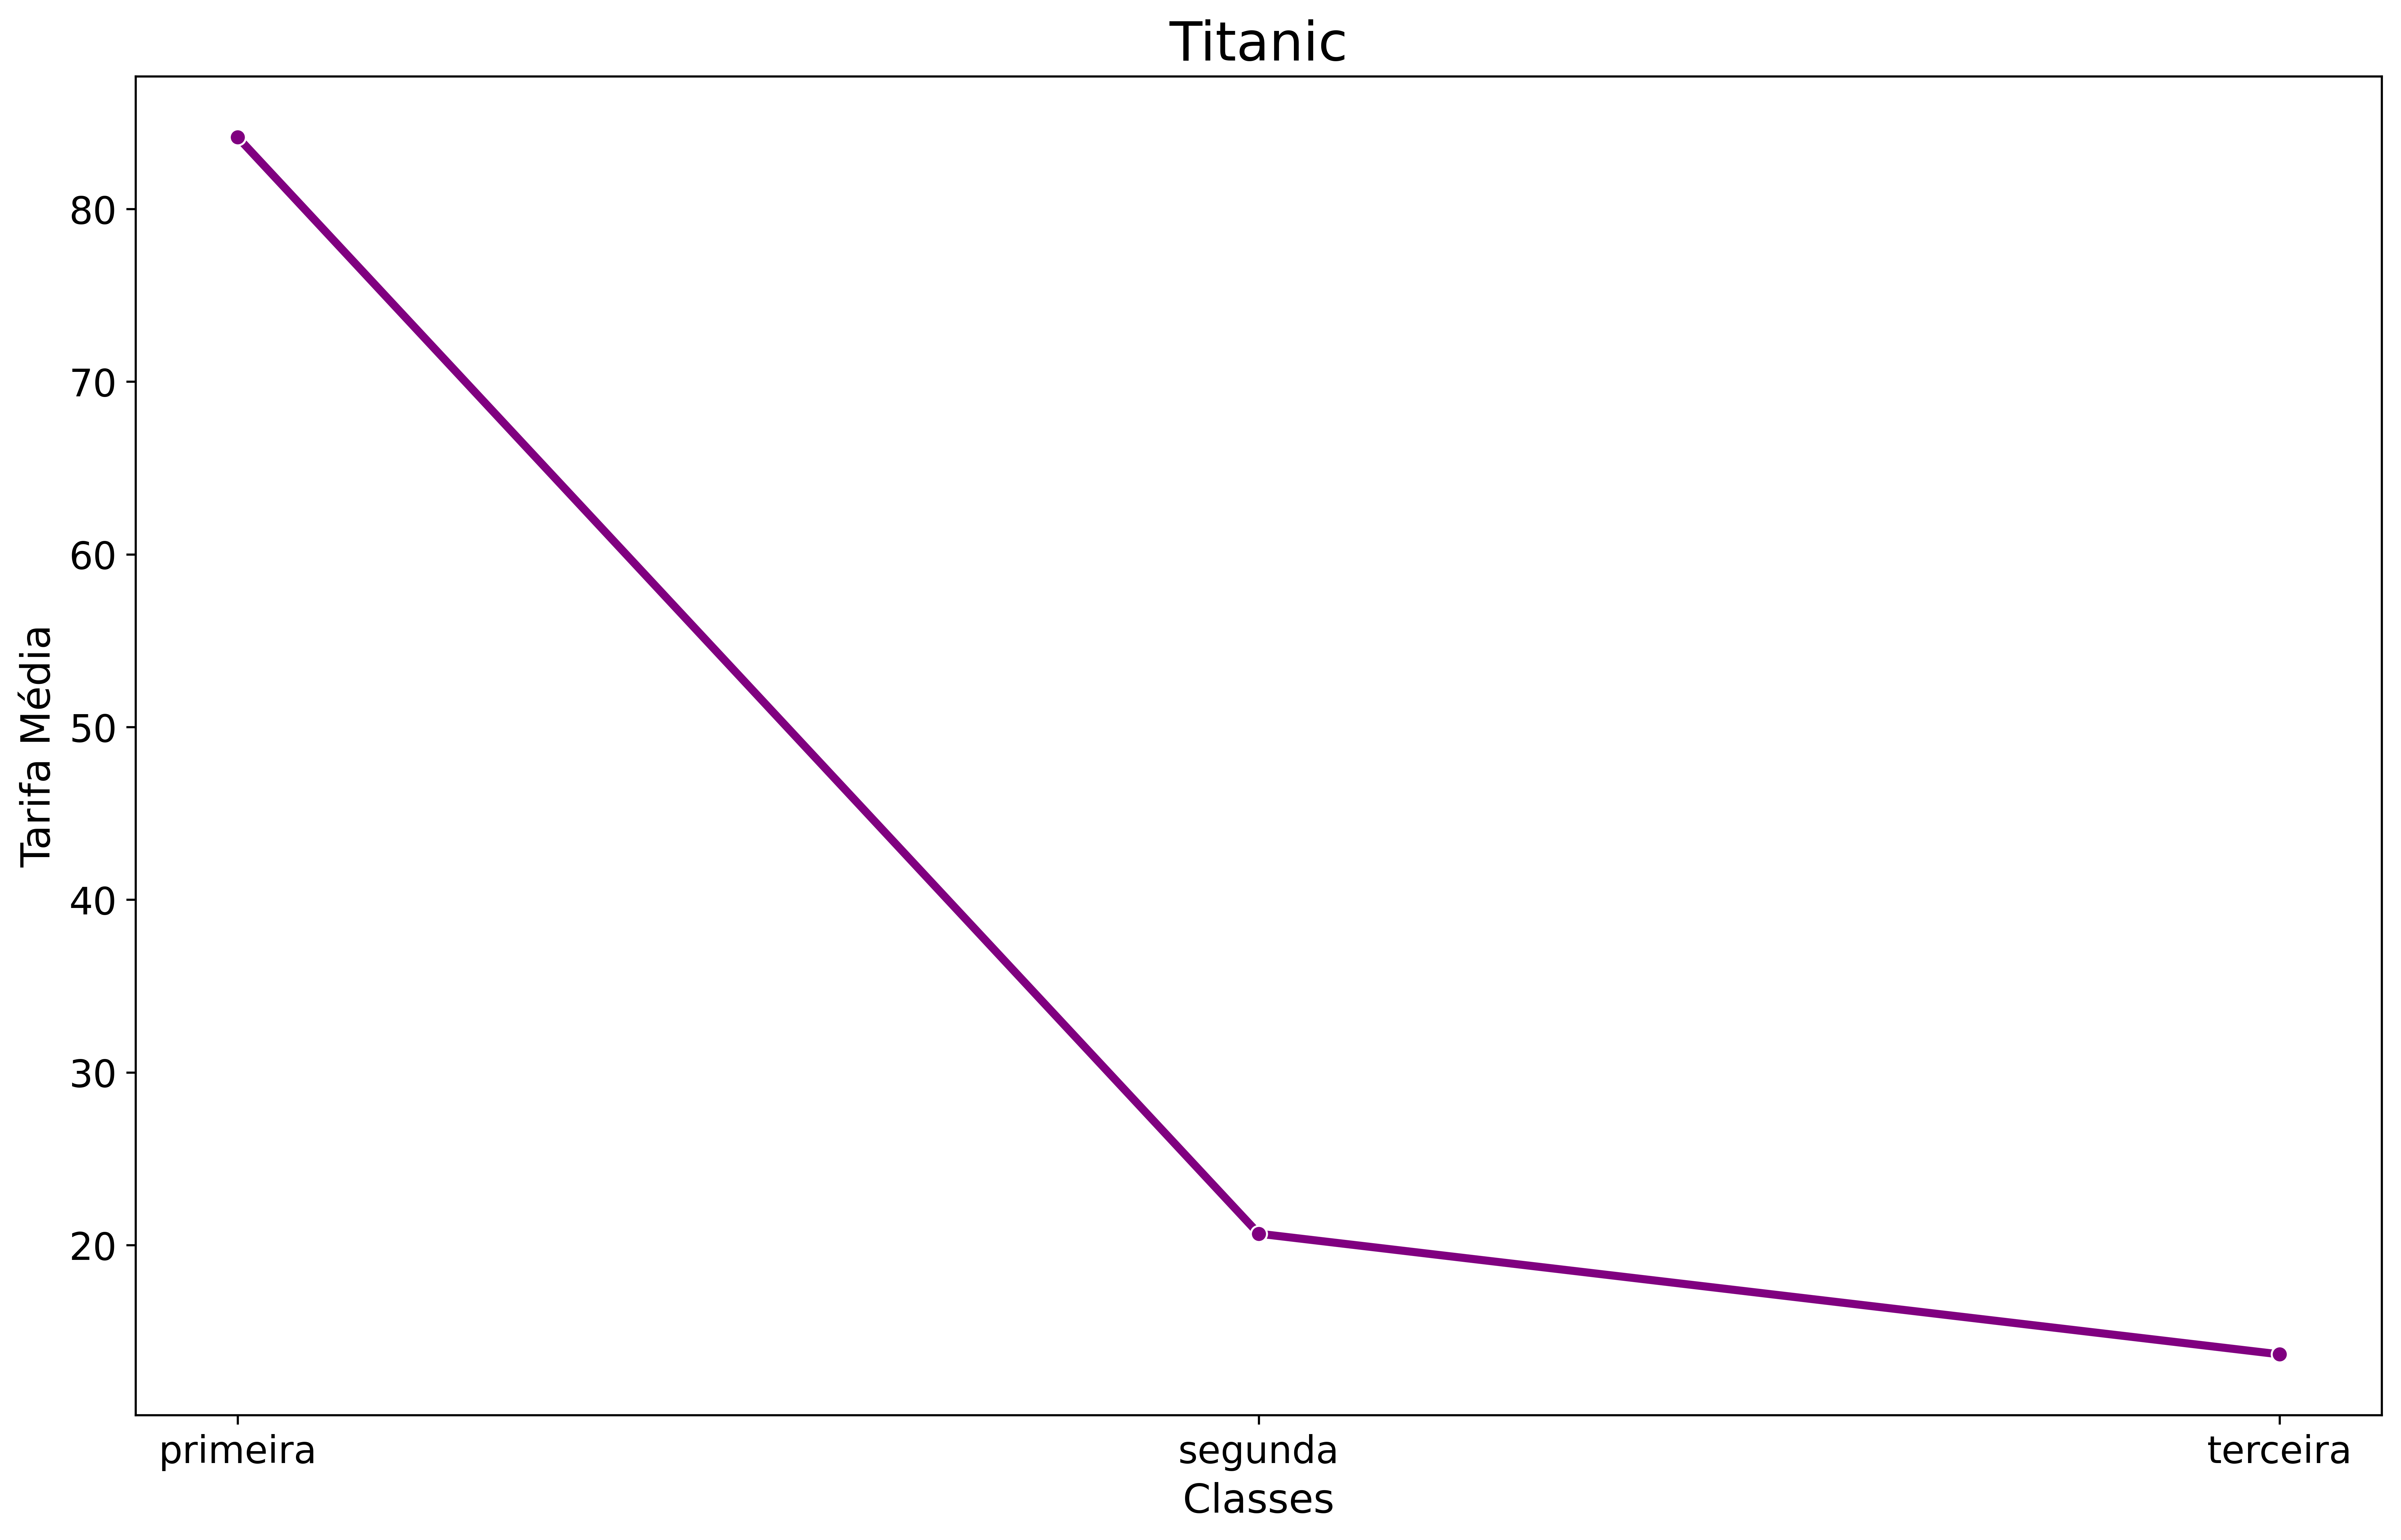

In [60]:
# lineplot - gráfico de linha
# usado index porque a classe
# deixou de ser variável passando a ser index
# marker - marcador de cada categoria
# linewidth- expessura da linha

plt.figure(figsize=(15,9), dpi=600)
sns.lineplot(data=dados_linha, x=dados_linha.index, y='valor_tarifa', marker='o', linewidth=3, color='purple')
plt.title('Titanic',fontsize=20)
plt.xlabel('Classes',fontsize=15)
plt.ylabel('Tarifa Média',fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# só para referenciar o gráfico de linha,
# pois não temos uma serie temporal.

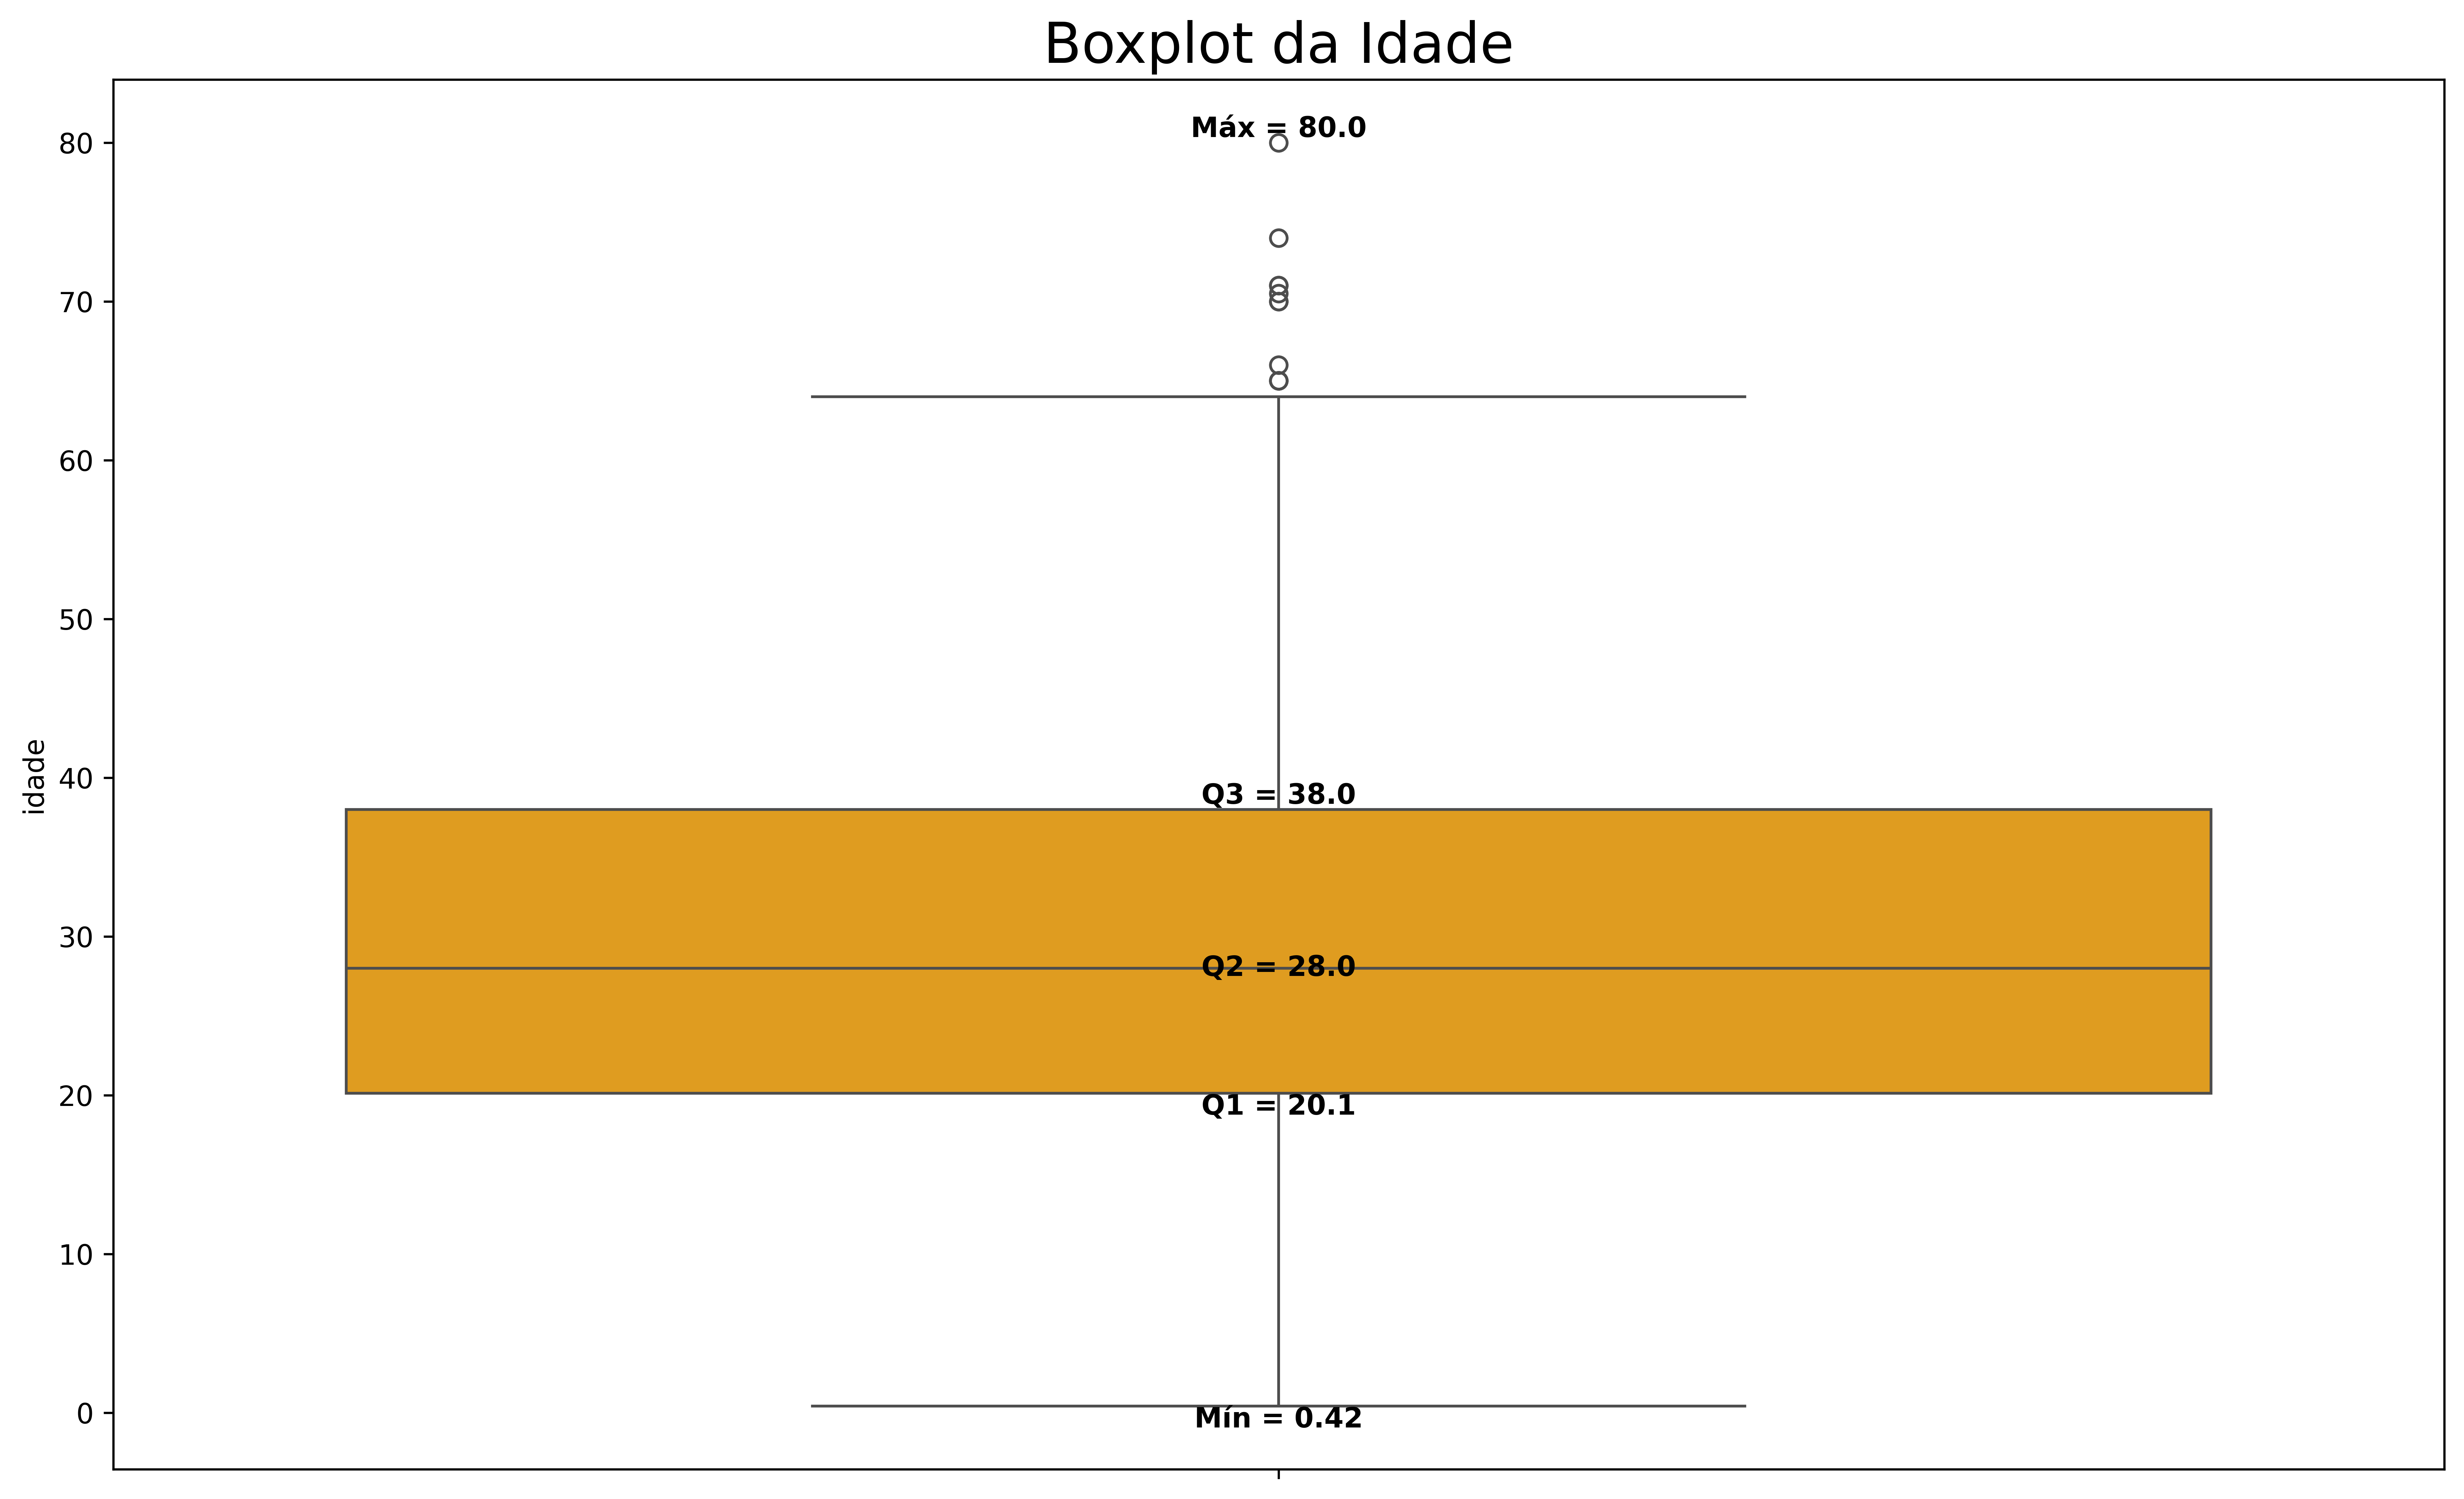

In [61]:
# Boxplot(gráfico de caixa) representa os quartis


# Gráfico para representar as medidas de posição de variáveis métricas
# Calcula as estatísticas
minimo = titanic['idade'].min()
q1 = titanic['idade'].quantile(q = 0.25)
q2 = titanic['idade'].median()
q3 = titanic['idade'].quantile(q = 0.75)
maximo = titanic['idade'].max()


plt.figure(figsize=(15,9), dpi=600)
sns.boxplot(y=titanic['idade'], color='orange')

# Adiciona os textos no gráfico
# ha- posição horizontal o centro
# va- posição vertical faz ajuste fino no gráfico
# fontweight 'bold'- fonte em negrito

plt.text(0, minimo, f'Mín = {minimo}', ha='center', va='top', fontweight='bold')
plt.text(0, q1, f'Q1 = {q1:.1f}', ha='center', va='top', fontweight='bold')
plt.text(0, q2, f'Q2 = {q2:.1f}', ha='center', va='center', fontweight='bold')
plt.text(0, q3, f'Q3 = {q3:.1f}', ha='center', va='bottom', fontweight='bold')
plt.text(0, maximo, f'Máx = {maximo}', ha='center', va='bottom', fontweight='bold')

plt.title('Boxplot da Idade',fontsize=20)
plt.show()





Interpretação do Boxplot

**Idade**

 mínima = 0,42

 Q1 = 20 anos -     25% tem menos de 21 anos na amostra

 Q2 = 28 anos mediana

 Q3 = 38 anos -    25 % tem mais de 38 anos na amostra

 máximo = 80 anos

# **RELATÓRIO DE ANÁLISE DE DADOS — TITANIC**

## 1. Introdução

Este relatório tem como objetivo analisar os dados dos passageiros do Titanic para identificar padrões relacionados à sobrevivência no naufrágio.

A análise foi realizada utilizando técnicas de análise exploratória de dados, permitindo compreender como fatores como sexo, idade, classe social e valor da passagem influenciaram as chances de sobrevivência dos passageiros.

Os dados utilizados são amplamente empregados em estudos de análise de dados e inteligência artificial.

--------------------------------------------------

## 2. Base de Dados

A base de dados contém informações sobre os passageiros do Titanic, incluindo características pessoais, sociais e informações da viagem.

### Informações analisadas

- Sobrevivência dos passageiros;
- Classe em que viajavam;
- Sexo;
- Idade;
- Valor da passagem;
- Porto de embarque;
- Quantidade de familiares a bordo.

--------------------------------------------------

## 3. Ferramentas Utilizadas

Durante a análise foram utilizadas as seguintes ferramentas:

- Python;
- Pandas;
- NumPy;
- Matplotlib;
- Seaborn;
- Jupyter Notebook.

--------------------------------------------------

## 4. Tratamento dos Dados

Antes da realização das análises, foi necessário tratar os dados para garantir maior qualidade nas informações.

### Etapas realizadas

- Verificação de dados ausentes;
- Preenchimento de informações faltantes;
- Organização das colunas;
- Verificação dos tipos de dados;
- Remoção de informações inconsistentes.

Foram identificadas informações ausentes principalmente nas colunas de idade, cabine e porto de embarque.

As idades ausentes foram preenchidas utilizando a mediana. A coluna de cabine foi removida devido à grande quantidade de dados faltantes.

--------------------------------------------------

## 5. Análise Exploratória dos Dados

### Distribuição dos passageiros por classe

A maior parte dos passageiros estava concentrada na terceira classe, indicando predominância de passageiros das classes econômicas mais baixas.

A primeira classe possuía menor quantidade de passageiros, porém com melhores condições e maior nível econômico.

--------------------------------------------------

### Sobrevivência por sexo

As mulheres apresentaram taxas de sobrevivência significativamente maiores em comparação aos homens.

Esse resultado está relacionado à prioridade dada a mulheres e crianças durante o resgate.

--------------------------------------------------

### Sobrevivência por classe social

Os passageiros da primeira classe tiveram maiores chances de sobrevivência quando comparados aos passageiros da terceira classe.

Esse resultado demonstra que fatores sociais e econômicos influenciaram diretamente as chances de sobrevivência.

--------------------------------------------------

### Análise da idade

A maior parte dos passageiros possuía idade entre 20 e 40 anos.

Também foi observado que crianças apresentaram taxas de sobrevivência maiores em comparação aos adultos.

--------------------------------------------------

### Valor das passagens

Passageiros que pagaram valores mais altos pelas passagens apresentaram maiores índices de sobrevivência.

Isso reforça a relação entre condição econômica e acesso às áreas prioritárias de resgate.

--------------------------------------------------

### Familiares a bordo

Passageiros acompanhados por pequenos grupos familiares apresentaram maiores chances de sobrevivência em comparação àqueles que viajavam sozinhos.

Famílias muito grandes apresentaram menores taxas de sobrevivência.

--------------------------------------------------

## 6. Principais Descobertas

Durante a análise, foram identificados alguns padrões importantes:

- Mulheres sobreviveram mais do que homens;
- Passageiros da primeira classe tiveram maiores chances de sobrevivência;
- Crianças foram priorizadas durante o resgate;
- Passageiros com passagens mais caras apresentaram maior taxa de sobrevivência;
- A condição social influenciou diretamente nas chances de sobrevivência.

--------------------------------------------------

## 7. Conclusão

A análise dos dados do Titanic permitiu identificar fatores importantes relacionados à sobrevivência dos passageiros.

Os resultados mostraram que sexo, idade, classe social e valor da passagem tiveram forte influência nas chances de sobrevivência durante o naufrágio.

Além disso, a análise demonstrou como técnicas de análise de dados podem auxiliar na identificação de padrões e na interpretação de informações relevantes.

O desenvolvimento deste projeto contribuiu para a prática de tratamento de dados, criação de gráficos e interpretação de resultados utilizando Python.